In [58]:
from rdkit import Chem
import pandas as pd
from chembl_structure_pipeline import standardizer
from rdkit import RDLogger
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit.Chem import Draw
from rdkit.Chem import MACCSkeys
from rdkit.Chem import rdFingerprintGenerator
from collections import Counter
from sklearn import model_selection as ms
from sklearn import ensemble
from sklearn.metrics import mean_squared_error
import numpy as np
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
from sklearn import decomposition
import xgboost as xg


In [59]:
RDLogger.DisableLog('rdApp.*')    

### Načtení dat a standardizace molekul

Stáhly jsme si z ChEMBLu IC50 aktivity pro histaminový receptor [H3](https://www.ebi.ac.uk/chembl/explore/target/CHEMBL264)

In [60]:
df_h3 = pd.read_csv("IC50_H3_receptor.csv", delimiter = ";")
df_h3

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL1222870,NaN,NaN,434.56,0.0,3.90,2f,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2CCN(C3CCCCC3)CC2)cc1,IC50,'=',...,CHEMBL1221264,1,Scientific Literature,Bioorg Med Chem Lett,2010,NaN,NaN,NaN,NaN,285.00
1,CHEMBL1223009,NaN,NaN,432.55,0.0,3.65,3e,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2C[C@H]3CC[C@@H](C2...,IC50,'=',...,CHEMBL1221264,1,Scientific Literature,Bioorg Med Chem Lett,2010,NaN,NaN,NaN,NaN,516.00
2,CHEMBL1270059,NaN,NaN,297.44,0.0,3.86,"8, enantiomer",C[C@@H]1C[C@@](O)(CCc2cccc3ccccc23)[C@@H](C)CN1C,IC50,'=',...,CHEMBL1268880,1,Scientific Literature,Bioorg Med Chem Lett,2010,CHEMBL3308396,NaN,NaN,NaN,2.00
3,CHEMBL2403548,NaN,NaN,395.52,0.0,4.76,8a,Cc1cc(N2CC[C@H](N3CCC[C@H]3C)C2)ccc1NC(=O)c1cc...,IC50,'=',...,CHEMBL2401654,1,Scientific Literature,Bioorg Med Chem Lett,2013,NaN,NaN,NaN,NaN,0.66
4,CHEMBL6005581,NaN,NaN,586.63,2.0,6.06,BDBM438125,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OC2C...,IC50,'=',...,CHEMBL5729267,37,BindingDB Patent Bioactivity Data,NaN,2022,NaN,NaN,NaN,NaN,50.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,CHEMBL5570657,NaN,NaN,408.59,0.0,4.58,XX,C[C@@H]1CCCN1CCCOc1ccc2c(c1)CC[C@H]1C3=CCC(=O)...,IC50,'=',...,CHEMBL5528071,1,Scientific Literature,J Med Chem,2024,NaN,TIME = 0.1667 hr,ANTAGONIST,NaN,9.20
1018,CHEMBL5568763,NaN,NaN,410.60,0.0,4.66,XXI,C[C@@H]1CCCN1CCCOc1ccc2c(c1)CC[C@@H]1[C@@H]2CC...,IC50,'=',...,CHEMBL5528071,1,Scientific Literature,J Med Chem,2024,NaN,TIME = 0.1667 hr,ANTAGONIST,NaN,2.60
1019,CHEMBL260374,THIOPERAMIDE,NaN,292.45,0.0,2.80,BDBM22914,S=C(NC1CCCCC1)N1CCC(c2cnc[nH]2)CC1,IC50,'=',...,CHEMBL5729658,37,BindingDB Patent Bioactivity Data,NaN,2023,NaN,NaN,NaN,NaN,140.00
1020,CHEMBL5915995,NaN,NaN,503.54,2.0,6.46,BDBM438114,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OCCC...,IC50,'=',...,CHEMBL5729267,37,BindingDB Patent Bioactivity Data,NaN,2022,NaN,NaN,NaN,NaN,10.50


In [61]:
df = df_h3[["Molecule ChEMBL ID", "Smiles"]]
df.set_index("Molecule ChEMBL ID", inplace=True)
df

,Smiles
Molecule ChEMBL ID,
CHEMBL1222870,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2CCN(C3CCCCC3)CC2)cc1
CHEMBL1223009,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2C[C@H]3CC[C@@H](C2...
CHEMBL1270059,C[C@@H]1C[C@@](O)(CCc2cccc3ccccc23)[C@@H](C)CN1C
CHEMBL2403548,Cc1cc(N2CC[C@H](N3CCC[C@H]3C)C2)ccc1NC(=O)c1cc...
CHEMBL6005581,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OC2C...
...,...
CHEMBL5570657,C[C@@H]1CCCN1CCCOc1ccc2c(c1)CC[C@H]1C3=CCC(=O)...
CHEMBL5568763,C[C@@H]1CCCN1CCCOc1ccc2c(c1)CC[C@@H]1[C@@H]2CC...
CHEMBL260374,S=C(NC1CCCCC1)N1CCC(c2cnc[nH]2)CC1


Přidáme mol objekt vytvořený ze SMILES.

In [62]:
df["mol"] = df["Smiles"].apply(lambda x: Chem.MolFromSmiles(x) if isinstance(x, str) else None)

In [63]:
failed_count = df["mol"].isna().sum()
print(f"Nepodařilo se vytvořit {failed_count} molekul.")

Nepodařilo se vytvořit 0 molekul.


Použijeme standardizaci, kdy dojde k odfiltrování solí, kovů, zbavení se nábojů,...

In [64]:
df['mol'] = df['mol'].apply(lambda x: standardizer.standardize_mol(x) if x is not None else None)

In [65]:
df

,Smiles,mol
Molecule ChEMBL ID,,
CHEMBL1222870,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2CCN(C3CCCCC3)CC2)cc1,<rdkit.Chem.rdchem.Mol object at 0x344e82340>
CHEMBL1223009,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2C[C@H]3CC[C@@H](C2...,<rdkit.Chem.rdchem.Mol object at 0x344e824d0>
CHEMBL1270059,C[C@@H]1C[C@@](O)(CCc2cccc3ccccc23)[C@@H](C)CN1C,<rdkit.Chem.rdchem.Mol object at 0x344e818a0>
CHEMBL2403548,Cc1cc(N2CC[C@H](N3CCC[C@H]3C)C2)ccc1NC(=O)c1cc...,<rdkit.Chem.rdchem.Mol object at 0x344e82570>
CHEMBL6005581,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OC2C...,<rdkit.Chem.rdchem.Mol object at 0x344e82ed0>
...,...,...
CHEMBL5570657,C[C@@H]1CCCN1CCCOc1ccc2c(c1)CC[C@H]1C3=CCC(=O)...,<rdkit.Chem.rdchem.Mol object at 0x344ec6070>
CHEMBL5568763,C[C@@H]1CCCN1CCCOc1ccc2c(c1)CC[C@@H]1[C@@H]2CC...,<rdkit.Chem.rdchem.Mol object at 0x344ec5f30>
CHEMBL260374,S=C(NC1CCCCC1)N1CCC(c2cnc[nH]2)CC1,<rdkit.Chem.rdchem.Mol object at 0x344ec5f80>


### Deskriptory

V RDkitu existuje mnoho deskriptorů - seznam všech [zde](https://www.rdkit.org/docs/GettingStartedInPython.html#list-of-available-descriptors) . 
- Jednotlivé deskriptory lze počítat pomocí modulu `rdkit.Chem.Descriptors`
- Pomocí funkce `CalcMolDescriptors()` lze spočítat všechny dostupné deskriptory pro molekulu. Tato funkce vrací slovník, kde název deskriptoru je klíč a hodnota je hodnota deskriptoru, ale my použijeme napočítání deskriptorů jednotlivě 

In [66]:
df['MolecularWeight'] = df['mol'].apply(lambda x: Descriptors.MolWt(x) if x is not None else None)
df['LogP'] = df['mol'].apply(lambda x: Descriptors.MolLogP(x) if x is not None else None)
df['HBD'] = df['mol'].apply(lambda x: Descriptors.NumHDonors(x) if x is not None else None)
df['HBA'] = df['mol'].apply(lambda x: Descriptors.NumHAcceptors(x) if x is not None else None)
df.head()

,Smiles,mol,MolecularWeight,LogP,HBD,HBA
Molecule ChEMBL ID,,,,,,
CHEMBL1222870,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2CCN(C3CCCCC3)CC2)cc1,<rdkit.Chem.rdchem.Mol object at 0x344e82340>,434.563,3.90020,0,5
CHEMBL1223009,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2C[C@H]3CC[C@@H](C2...,<rdkit.Chem.rdchem.Mol object at 0x344e824d0>,432.547,3.65100,0,5
CHEMBL1270059,C[C@@H]1C[C@@](O)(CCc2cccc3ccccc23)[C@@H](C)CN1C,<rdkit.Chem.rdchem.Mol object at 0x344e818a0>,297.442,3.86360,1,2
CHEMBL2403548,Cc1cc(N2CC[C@H](N3CCC[C@H]3C)C2)ccc1NC(=O)c1cc...,<rdkit.Chem.rdchem.Mol object at 0x344e82570>,395.522,4.75784,1,3
CHEMBL6005581,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OC2C...,<rdkit.Chem.rdchem.Mol object at 0x344e82ed0>,586.627,6.06312,0,5


### Lipinského pravidlo pěti
Lipinského pravidlo pěti slouží k odhadu orální biodostupnosti molekuly. Za špatně absorbovatelnou je považována molekula porušující více než jedno z následujících podmínek:

- molekulová hmotnost <= 500 Da
- počet donorů vodíkových vazeb <= 5
- počet akceptorů vodíkových vazeb <= 10
- LogP <= 5

In [67]:
df["vHBA"] = df["HBA"].apply(lambda x: x > 10)
df["vHBD"] = df["HBD"].apply(lambda x: x > 5)
df["vMW"] = df["MolecularWeight"].apply(lambda x: x > 500)
df["vLogP"] = df["LogP"].apply(lambda x: x > 5)
df["Lipinski"] = df[["vHBA", "vHBD", "vMW", "vLogP"]].sum(axis = 1) <= 1

In [68]:
print(f"Z celkového počtu {len(df_h3)} prošlo Lipinského pravidlem pěti {df['Lipinski'].sum()} molekul.")

Z celkového počtu 1022 prošlo Lipinského pravidlem pěti 912 molekul.


In [69]:
df.head()

,Smiles,mol,MolecularWeight,LogP,HBD,HBA,vHBA,vHBD,vMW,vLogP,Lipinski
Molecule ChEMBL ID,,,,,,,,,,,
CHEMBL1222870,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2CCN(C3CCCCC3)CC2)cc1,<rdkit.Chem.rdchem.Mol object at 0x344e82340>,434.563,3.90020,0,5,False,False,False,False,True
CHEMBL1223009,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2C[C@H]3CC[C@@H](C2...,<rdkit.Chem.rdchem.Mol object at 0x344e824d0>,432.547,3.65100,0,5,False,False,False,False,True
CHEMBL1270059,C[C@@H]1C[C@@](O)(CCc2cccc3ccccc23)[C@@H](C)CN1C,<rdkit.Chem.rdchem.Mol object at 0x344e818a0>,297.442,3.86360,1,2,False,False,False,False,True
CHEMBL2403548,Cc1cc(N2CC[C@H](N3CCC[C@H]3C)C2)ccc1NC(=O)c1cc...,<rdkit.Chem.rdchem.Mol object at 0x344e82570>,395.522,4.75784,1,3,False,False,False,False,True
CHEMBL6005581,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OC2C...,<rdkit.Chem.rdchem.Mol object at 0x344e82ed0>,586.627,6.06312,0,5,False,False,True,True,False


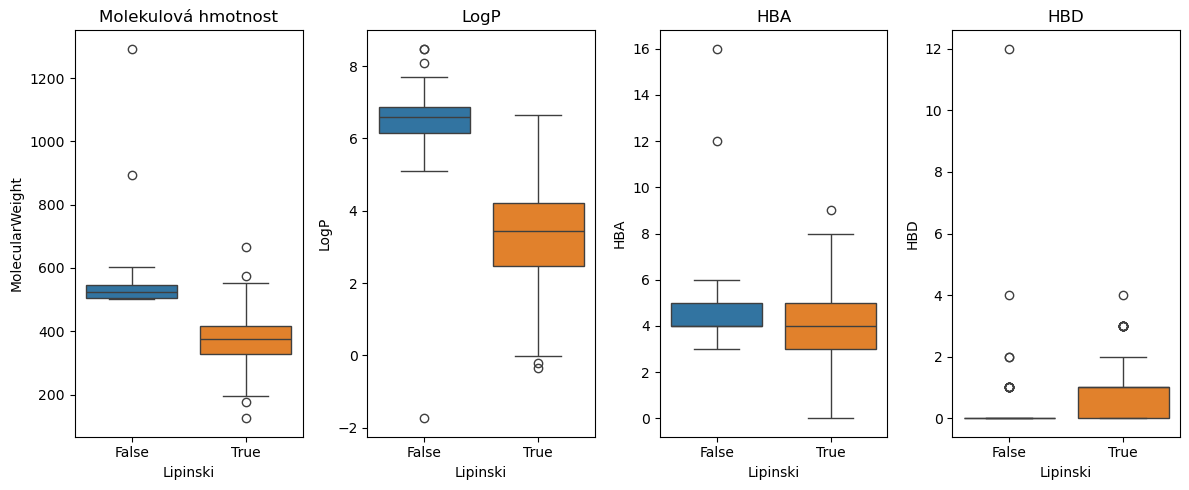

In [70]:
fig, axes = plt.subplots(1, 4, figsize=(12, 5))

sns.boxplot(data=df, y='MolecularWeight', x='Lipinski', hue='Lipinski', ax=axes[0], legend = False)
axes[0].set_title('Molekulová hmotnost')

sns.boxplot(data=df, y='LogP', x='Lipinski', hue='Lipinski', ax=axes[1], legend = False)
axes[1].set_title('LogP')

sns.boxplot(data=df, y='HBA', x='Lipinski', hue='Lipinski', ax=axes[2], legend = False)
axes[2].set_title('HBA')

sns.boxplot(data=df, y='HBD', x='Lipinski', hue='Lipinski', ax=axes[3], legend = False)
axes[3].set_title('HBD')

plt.tight_layout()
plt.show()

K vyřazení molekul po aplikování Lipinského pravidla pěti došlo pravděpodobně z důvodu vyšší molekulové hmotnosti či vyšší hodnoty logP, u několika případů pak přesáhl dovolenou hranici i počet akceptorů vodíkových vazeb.

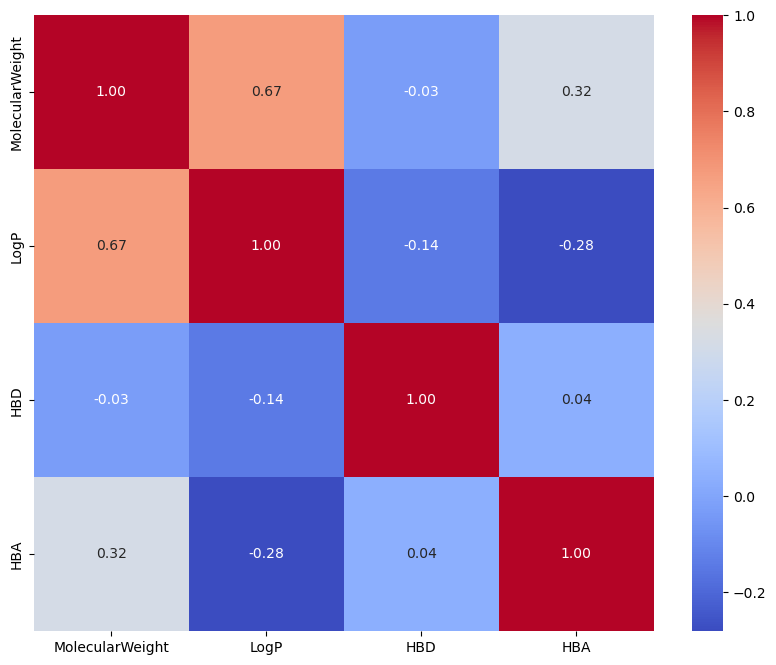

In [71]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

Z této heatmapy je patrné, že nejvíce spolu koreluje molekulová hmotnost s logP.

### Porovnání s molekulami z jiných zdrojů
Podíváme se na porovnání s datasety zinc, drugbank a mTOR, které jsme používali na cvičení

In [72]:
suppl = Chem.SDMolSupplier('/Users/simona/Dev/cdd2026/data/drugbank.sdf')

data = []
for mol in suppl:
    if mol is None: 
        continue
    try:
        row = {
            "source": "drugbank",
            "mol": mol,
            "id": mol.GetProp("DATABASE_ID"),
            "name": mol.GetProp("GENERIC_NAME") if mol.HasProp("GENERIC_NAME") else None
        }
        data.append(row)
    except KeyError:
        continue

drugbank_df = pd.DataFrame(data)   
drugbank_df.set_index("id", inplace = True)
drugbank_df = drugbank_df.drop(columns = ["name"])

In [73]:
zinc_df = pd.read_csv("/Users/simona/Dev/cdd2026/data/zinc_random_structures.txt", delimiter = " ")
zinc_df.rename(columns={"zincid":"id"}, inplace = True)
zinc_df.set_index("id", inplace = True)
zinc_df["source"] = "zinc"
zinc_df["mol"] = zinc_df["SMILES"].apply(lambda x: Chem.MolFromSmiles(x))
zinc_df.drop(columns=["tranche", "SMILES"], inplace = True)

In [74]:
mtor_df = pd.read_csv("/Users/simona/Dev/cdd2026/data/chembl_mtor_ic50.csv", delimiter=";", usecols = ["Molecule ChEMBL ID", "Smiles"])
mtor_df.rename(columns={"Molecule ChEMBL ID":"id"}, inplace = True)
mtor_df["source"] = "mtor"
mtor_df.set_index("id", inplace = True)
mtor_df["mol"] = mtor_df["Smiles"].apply(lambda x: Chem.MolFromSmiles(x))
mtor_df.drop(columns = ["Smiles"], inplace = True)

Spojením všech načtených dataframů ze zincu, drugbank a mtor si připravím srovnávací dataset.

In [75]:
structures = pd.concat([mtor_df, zinc_df, drugbank_df])
structures

,source,mol
id,,
CHEMBL1773577,mtor,<rdkit.Chem.rdchem.Mol object at 0x3242db5a0>
CHEMBL1773561,mtor,<rdkit.Chem.rdchem.Mol object at 0x3242db450>
CHEMBL1773077,mtor,<rdkit.Chem.rdchem.Mol object at 0x3242db3e0>
CHEMBL1773580,mtor,<rdkit.Chem.rdchem.Mol object at 0x3242db370>
CHEMBL1773578,mtor,<rdkit.Chem.rdchem.Mol object at 0x3242db300>
...,...,...
DB13154,drugbank,<rdkit.Chem.rdchem.Mol object at 0x348ef8510>
DB13155,drugbank,<rdkit.Chem.rdchem.Mol object at 0x348ef8580>
DB13156,drugbank,<rdkit.Chem.rdchem.Mol object at 0x348ef85f0>


Vytvoříme mol objekty a napočítáme deskriptory a splnění podmínek pro Lipinského pravidlo pěti

In [76]:
structures['mol'] = structures['mol'].apply(lambda x: standardizer.standardize_mol(x))

In [77]:
structures['MolecularWeight'] = structures['mol'].apply(lambda x: Descriptors.MolWt(x) if x is not None else None)
structures['LogP'] = structures['mol'].apply(lambda x: Descriptors.MolLogP(x) if x is not None else None)
structures['HBD'] = structures['mol'].apply(lambda x: Descriptors.NumHDonors(x) if x is not None else None)
structures['HBA'] = structures['mol'].apply(lambda x: Descriptors.NumHAcceptors(x) if x is not None else None)
structures.head()

,source,mol,MolecularWeight,LogP,HBD,HBA
id,,,,,,
CHEMBL1773577,mtor,<rdkit.Chem.rdchem.Mol object at 0x11a777600>,443.485,3.65160,2,7
CHEMBL1773561,mtor,<rdkit.Chem.rdchem.Mol object at 0x11a7776f0>,390.468,4.59912,1,6
CHEMBL1773077,mtor,<rdkit.Chem.rdchem.Mol object at 0x11a777240>,406.467,4.29930,1,7
CHEMBL1773580,mtor,<rdkit.Chem.rdchem.Mol object at 0x11a7772e0>,443.485,3.65160,2,7
CHEMBL1773578,mtor,<rdkit.Chem.rdchem.Mol object at 0x11a7771f0>,457.512,3.67590,1,7


In [78]:
structures["vHBA"] = structures["HBA"].apply(lambda x: x > 10)
structures["vHBD"] = structures["HBD"].apply(lambda x: x > 5)
structures["vMW"] = structures["MolecularWeight"].apply(lambda x: x > 500)
structures["vLogP"] = structures["LogP"].apply(lambda x: x > 5)
structures["Lipinski"] = structures[["vHBA", "vHBD", "vMW", "vLogP"]].sum(axis = 1) <= 1

In [79]:
df["source"] = "H3"

In [80]:
all_structures = pd.concat([df, structures]) 

In [81]:
all_structures

,Smiles,mol,MolecularWeight,LogP,HBD,HBA,vHBA,vHBD,vMW,vLogP,Lipinski,source
CHEMBL1222870,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2CCN(C3CCCCC3)CC2)cc1,<rdkit.Chem.rdchem.Mol object at 0x344e82340>,434.563,3.90020,0,5,False,False,False,False,True,H3
CHEMBL1223009,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2C[C@H]3CC[C@@H](C2...,<rdkit.Chem.rdchem.Mol object at 0x344e824d0>,432.547,3.65100,0,5,False,False,False,False,True,H3
CHEMBL1270059,C[C@@H]1C[C@@](O)(CCc2cccc3ccccc23)[C@@H](C)CN1C,<rdkit.Chem.rdchem.Mol object at 0x344e818a0>,297.442,3.86360,1,2,False,False,False,False,True,H3
CHEMBL2403548,Cc1cc(N2CC[C@H](N3CCC[C@H]3C)C2)ccc1NC(=O)c1cc...,<rdkit.Chem.rdchem.Mol object at 0x344e82570>,395.522,4.75784,1,3,False,False,False,False,True,H3
CHEMBL6005581,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OC2C...,<rdkit.Chem.rdchem.Mol object at 0x344e82ed0>,586.627,6.06312,0,5,False,False,True,True,False,H3
...,...,...,...,...,...,...,...,...,...,...,...,...
DB13154,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0040>,128.558,2.04560,1,1,False,False,False,False,True,drugbank
DB13155,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac02c0>,340.284,-1.32270,5,9,False,False,False,False,True,drugbank
DB13156,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0270>,1115.249,1.54710,13,19,True,True,True,False,False,drugbank
DB13157,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0450>,330.422,-0.00030,0,5,False,False,False,False,True,drugbank


In [82]:
print(all_structures.groupby('source')['Lipinski'].sum()) 
print(all_structures["source"].value_counts())

source
H3           912
drugbank    6400
mtor        4358
zinc        7180
Name: Lipinski, dtype: int64
source
zinc        7180
drugbank    7120
mtor        4596
H3          1022
Name: count, dtype: int64


Text(0.5, 1.0, 'Procento molekul splňujících podmínky Ro5')

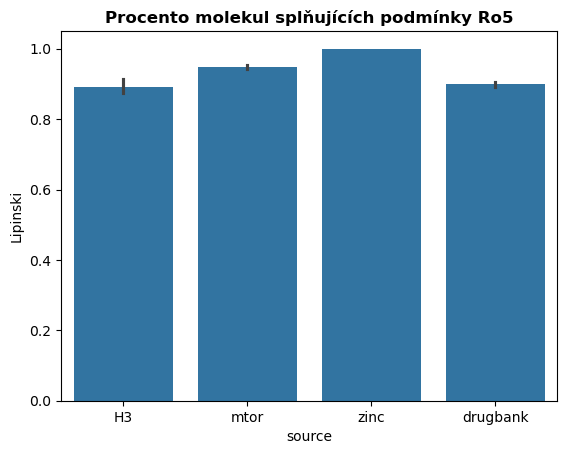

In [83]:
sns.barplot(data=all_structures, x="source", y="Lipinski")
plt.title("Procento molekul splňujících podmínky Ro5", fontsize=12, fontweight="bold")

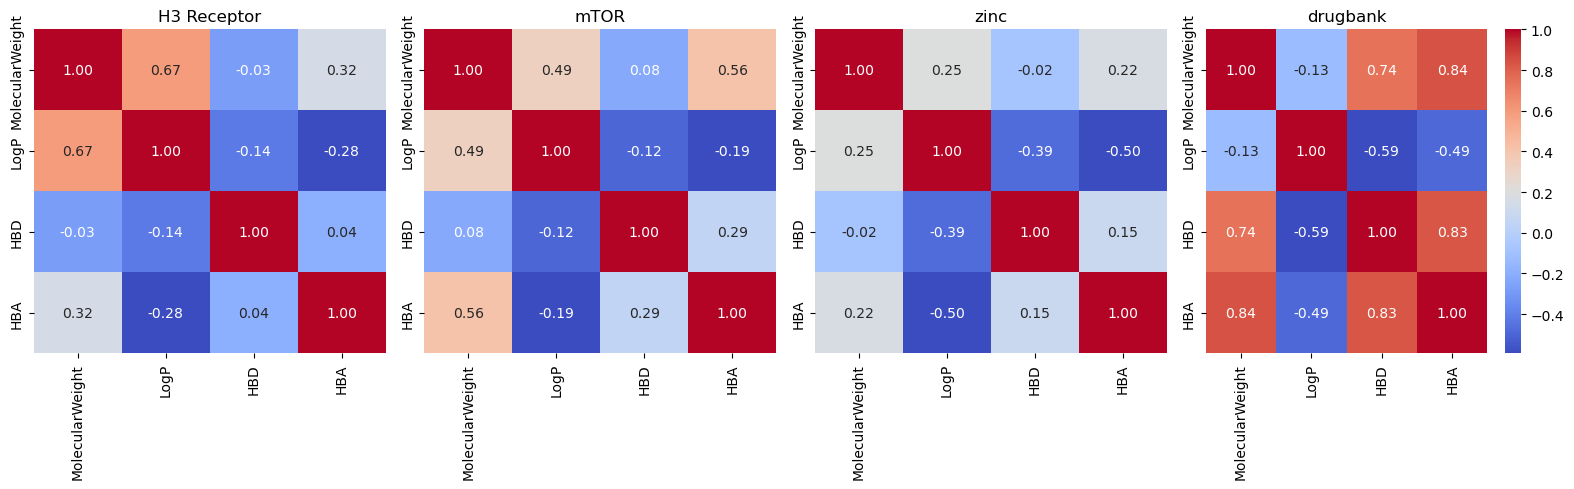

In [84]:
corr_h3 = df.select_dtypes(include=['number']).corr()
corr_mtor = structures[structures["source"]=="mtor"].select_dtypes(include=['number']).corr()
corr_zinc = structures[structures["source"]=="zinc"].select_dtypes(include=['number']).corr()
corr_drugbank = structures[structures["source"]=="drugbank"].select_dtypes(include=['number']).corr()

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

sns.heatmap(corr_h3, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0], cbar=False)
axes[0].set_title('H3 Receptor')

sns.heatmap(corr_mtor, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1],cbar=False)
axes[1].set_title('mTOR')

sns.heatmap(corr_zinc, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2],cbar=False)
axes[2].set_title('zinc')

sns.heatmap(corr_drugbank, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[3])
axes[3].set_title('drugbank')


plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Procento molekul porušujících podmínku z Ro5')

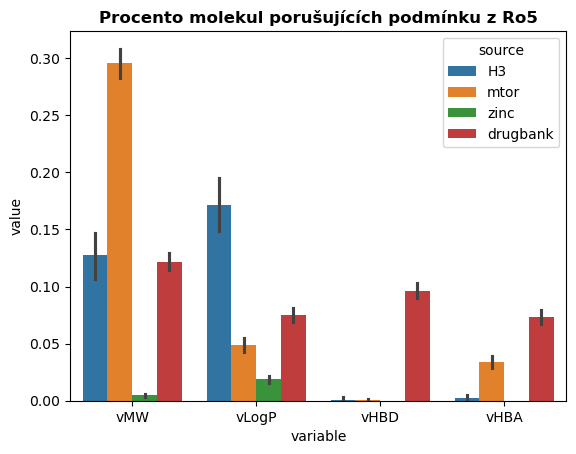

In [85]:
sns.barplot(data=all_structures.melt(["source"],["vMW", "vLogP", "vHBD", "vHBA"]), x="variable", y="value", hue="source")
plt.title("Procento molekul porušujících podmínku z Ro5", fontsize=12, fontweight="bold")

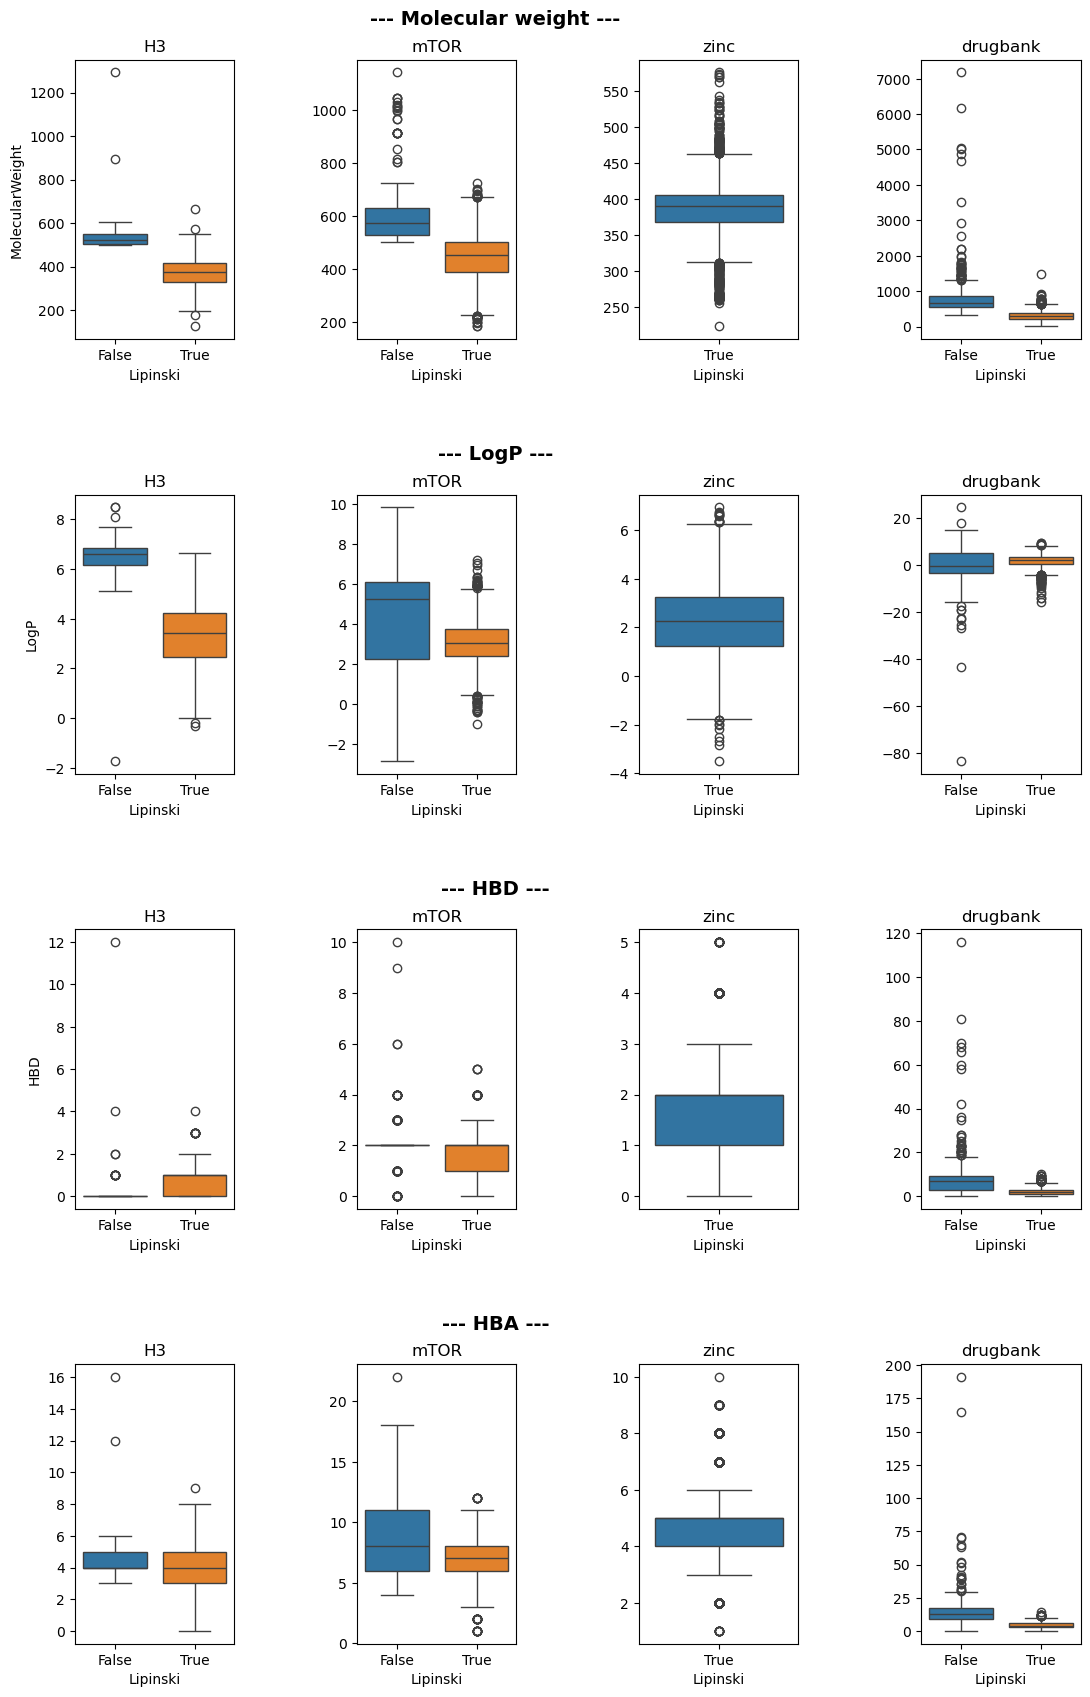

In [86]:
fig = plt.figure(figsize=(12, 17))
subfigs = fig.subfigures(4, 1, hspace=0.1)

# ---------------- 1. řádek grafů -------------------------
subfigs[0].suptitle('--- Molecular weight ---', fontsize=14, fontweight='bold')
subfigs[0].subplots_adjust(top=0.95)
axes_row1 = subfigs[0].subplots(1, 4)

sns.boxplot(data=all_structures[all_structures["source"]=="H3"], y='MolecularWeight', x='Lipinski', hue='Lipinski', ax=axes_row1[0], legend = False)
axes_row1[0].set_title('H3')
axes_row1[0].set_box_aspect(1.75)

sns.boxplot(data=all_structures[all_structures["source"]=="mtor"], y='MolecularWeight', x='Lipinski', hue='Lipinski', ax=axes_row1[1], legend = False)
axes_row1[1].set_title('mTOR')
axes_row1[1].set_ylabel('')
axes_row1[1].set_box_aspect(1.75)


sns.boxplot(data=all_structures[all_structures["source"]=="zinc"], y='MolecularWeight', x='Lipinski', hue='Lipinski', ax=axes_row1[2], legend = False)
axes_row1[2].set_title('zinc')
axes_row1[2].set_ylabel('')
axes_row1[2].set_box_aspect(1.75)

sns.boxplot(data=all_structures[all_structures["source"]=="drugbank"], y='MolecularWeight', x='Lipinski', hue='Lipinski', ax=axes_row1[3], legend = False)
axes_row1[3].set_title('drugbank')
axes_row1[3].set_ylabel('')
axes_row1[3].set_box_aspect(1.75)

# ---------------- 2. řádek grafů -------------------------
subfigs[1].suptitle('--- LogP ---', fontsize=14, fontweight='bold')
subfigs[1].subplots_adjust(top=0.95)
axes_row2 = subfigs[1].subplots(1, 4)

sns.boxplot(data=all_structures[all_structures["source"]=="H3"], y='LogP', x='Lipinski', hue='Lipinski', ax=axes_row2[0], legend = False)
axes_row2[0].set_title('H3')
axes_row2[0].set_box_aspect(1.75)

sns.boxplot(data=all_structures[all_structures["source"]=="mtor"], y='LogP', x='Lipinski', hue='Lipinski', ax=axes_row2[1], legend = False)
axes_row2[1].set_title('mTOR')
axes_row2[1].set_ylabel('')
axes_row2[1].set_box_aspect(1.75)

sns.boxplot(data=all_structures[all_structures["source"]=="zinc"], y='LogP', x='Lipinski', hue='Lipinski', ax=axes_row2[2], legend = False)
axes_row2[2].set_title('zinc')
axes_row2[2].set_ylabel('')
axes_row2[2].set_box_aspect(1.75)

sns.boxplot(data=all_structures[all_structures["source"]=="drugbank"], y='LogP', x='Lipinski', hue='Lipinski', ax=axes_row2[3], legend = False)
axes_row2[3].set_title('drugbank')
axes_row2[3].set_ylabel('')
axes_row2[3].set_box_aspect(1.75)

# ---------------- 3. řádek grafů -------------------------
subfigs[2].suptitle('--- HBD ---', fontsize=14, fontweight='bold')
subfigs[2].subplots_adjust(top=0.95)
axes_row3 = subfigs[2].subplots(1, 4)

sns.boxplot(data=all_structures[all_structures["source"]=="H3"], y='HBD', x='Lipinski', hue='Lipinski', ax=axes_row3[0], legend = False)
axes_row3[0].set_title('H3')
axes_row3[0].set_box_aspect(1.75)

sns.boxplot(data=all_structures[all_structures["source"]=="mtor"], y='HBD', x='Lipinski', hue='Lipinski', ax=axes_row3[1], legend = False)
axes_row3[1].set_title('mTOR')
axes_row3[1].set_ylabel('')
axes_row3[1].set_box_aspect(1.75)


sns.boxplot(data=all_structures[all_structures["source"]=="zinc"], y='HBD', x='Lipinski', hue='Lipinski', ax=axes_row3[2], legend = False)
axes_row3[2].set_title('zinc')
axes_row3[2].set_ylabel('')
axes_row3[2].set_box_aspect(1.75)

sns.boxplot(data=all_structures[all_structures["source"]=="drugbank"], y='HBD', x='Lipinski', hue='Lipinski', ax=axes_row3[3], legend = False)
axes_row3[3].set_title('drugbank')
axes_row3[3].set_ylabel('')
axes_row3[3].set_box_aspect(1.75)

# ---------------- 4. řádek grafů -------------------------
subfigs[3].suptitle('--- HBA ---', fontsize=14, fontweight='bold')
subfigs[3].subplots_adjust(top=0.95)
axes_row4 = subfigs[3].subplots(1, 4)

sns.boxplot(data=all_structures[all_structures["source"]=="H3"], y='HBA', x='Lipinski', hue='Lipinski', ax=axes_row4[0], legend = False)
axes_row4[0].set_title('H3')
axes_row4[0].set_ylabel('')
axes_row4[0].set_box_aspect(1.75)


sns.boxplot(data=all_structures[all_structures["source"]=="mtor"], y='HBA', x='Lipinski', hue='Lipinski', ax=axes_row4[1], legend = False)
axes_row4[1].set_title('mTOR')
axes_row4[1].set_ylabel('')
axes_row4[1].set_box_aspect(1.75)

sns.boxplot(data=all_structures[all_structures["source"]=="zinc"], y='HBA', x='Lipinski', hue='Lipinski', ax=axes_row4[2], legend = False)
axes_row4[2].set_title('zinc')
axes_row4[2].set_ylabel('')
axes_row4[2].set_box_aspect(1.75)


sns.boxplot(data=all_structures[all_structures["source"]=="drugbank"], y='HBA', x='Lipinski', hue='Lipinski', ax=axes_row4[3], legend = False)
axes_row4[3].set_title('drugbank')
axes_row4[3].set_ylabel('')
axes_row4[3].set_box_aspect(1.75)


plt.tight_layout()
plt.show()

### Vyhledávání podstruktur pomocí SMARTS

Nejprve se podíváme, jak vypadá samotný histamin, jelikož některé ligandy se ho snaží napodobovat, budeme následně hledat jako první podstrukturu imidazolový kruh v datasetu ligandů H3 receptoru a koukneme se i na zastoupení této podstruktury v ostatních datasetech.

Ligandy pro H3 receptor jsou nejčastěji navrhovány takto : Obecný farmakofor pro H3R antagonistu vypadá takto: 
<br>[**Bazická hlava**] — [**Linker**] — [**Centrální jádro / Spacer**] — [**Lipofilní / Polární skupina**].

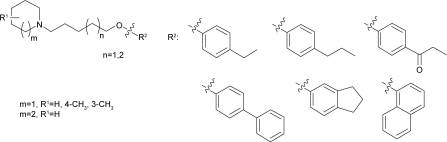

Obecná struktura ligandů testovaných ve článku https://pmc.ncbi.nlm.nih.gov/articles/PMC5135077/#f10-dddt-10-3879

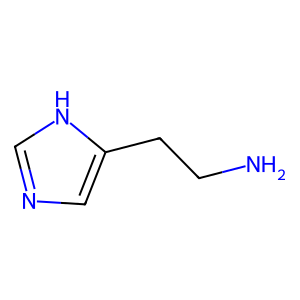

In [87]:
histamine = Chem.MolFromSmiles('C1=C(NC=N1)CCN')
Draw.MolToImage(histamine)

In [88]:
imidazol = Chem.MolFromSmarts('c1nccn1')

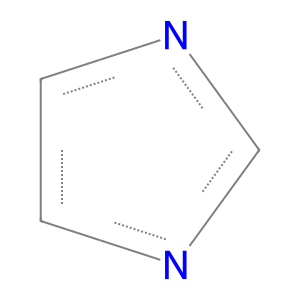

In [89]:
Draw.MolToImage(imidazol)

In [90]:
all_structures["sub_imidazol"] = all_structures["mol"].apply(lambda x: x.HasSubstructMatch(imidazol))

In [91]:
all_structures.groupby('source')['sub_imidazol'].sum()

source
H3           33
drugbank    616
mtor        728
zinc        614
Name: sub_imidazol, dtype: int64

In [92]:
sources = all_structures["source"].unique()
print("Procento molekul obsahujících imidazolový kruh:")
for source in sources:
    df_source = all_structures[all_structures["source"] == source]
    procento = df_source["sub_imidazol"].mean() * 100
    print(f" - {source}: {procento:.2f} %")

Procento molekul obsahujících imidazolový kruh:
 - H3: 3.23 %
 - mtor: 15.84 %
 - zinc: 8.55 %
 - drugbank: 8.65 %


To se tedy teorie příliš nepotvrdila, zkusíme se podívat na ne-imidazolové ligandy a vyhledat podstruktury **piperidin** a **pyrrolidin**

In [93]:
piperidine = Chem.MolFromSmarts('C1CCNCC1')

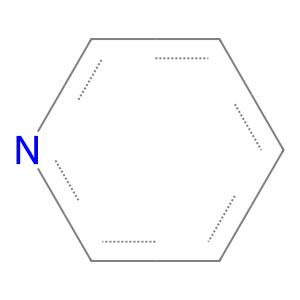

In [94]:
Draw.MolToImage(piperidine)

In [95]:
all_structures["sub_piperidine"] = all_structures["mol"].apply(lambda x: x.HasSubstructMatch(piperidine))

In [96]:
all_structures.groupby('source')['sub_piperidine'].sum()

source
H3           341
drugbank     450
mtor         634
zinc        1575
Name: sub_piperidine, dtype: int64

In [97]:
sources = all_structures["source"].unique()
print("Procento molekul obsahujících piperidin:")
for source in sources:
    df_source = all_structures[all_structures["source"] == source]
    procento = df_source["sub_piperidine"].mean() * 100
    print(f" - {source}: {procento:.2f} %")

Procento molekul obsahujících piperidin:
 - H3: 33.37 %
 - mtor: 13.79 %
 - zinc: 21.94 %
 - drugbank: 6.32 %


U piperidinu už to začíná být zajímavé..

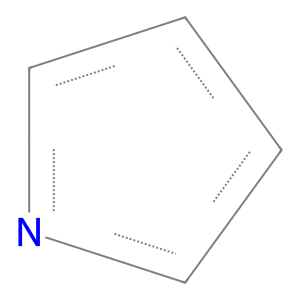

In [98]:
pyrrolidin = Chem.MolFromSmarts('C1CCNC1')
Draw.MolToImage(pyrrolidin)

In [99]:
all_structures["sub_pyrrolidine"] = all_structures["mol"].apply(lambda x: x.HasSubstructMatch(pyrrolidin))

In [100]:
all_structures.groupby('source')['sub_pyrrolidine'].sum()

source
H3           325
drugbank     401
mtor         297
zinc        1831
Name: sub_pyrrolidine, dtype: int64

In [101]:
sources = all_structures["source"].unique()
print("Procento molekul obsahujících pyrrolidin:")
for source in sources:
    df_source = all_structures[all_structures["source"] == source]
    procento = df_source["sub_pyrrolidine"].mean() * 100
    print(f" - {source}: {procento:.2f} %")

Procento molekul obsahujících pyrrolidin:
 - H3: 31.80 %
 - mtor: 6.46 %
 - zinc: 25.50 %
 - drugbank: 5.63 %


I u pyrrolidinu je mezi ligandy receptoru H3 přibližně třetina obsahující pyrrolidin. Podíváme se ještě na obsah tzv. linkerů.

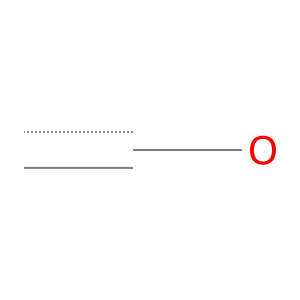

In [102]:
linker01 = Chem.MolFromSmarts('[OD2]([CC])')
Draw.MolToImage(linker01)

In [103]:
all_structures["sub_link"] = all_structures["mol"].apply(lambda x: x.HasSubstructMatch(linker01))

In [104]:
sources = all_structures["source"].unique()
print("Procento molekul obsahujících linker:")
for source in sources:
    df_source = all_structures[all_structures["source"] == source]
    procento = df_source["sub_link"].mean() * 100
    print(f" - {source}: {procento:.2f} %")

Procento molekul obsahujících linker:
 - H3: 54.60 %
 - mtor: 68.62 %
 - zinc: 43.90 %
 - drugbank: 42.13 %


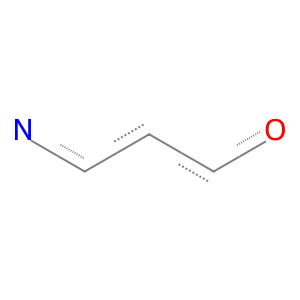

In [105]:
linker02 = Chem.MolFromSmarts('NCC[CH2]O')
Draw.MolToImage(linker02)

In [106]:
all_structures["sub_link02"] = all_structures["mol"].apply(lambda x: x.HasSubstructMatch(linker02))

sources = all_structures["source"].unique()
print("Procento molekul obsahujících 2. linker:")
for source in sources:
    df_source = all_structures[all_structures["source"] == source]
    procento = df_source["sub_link02"].mean() * 100
    print(f" - {source}: {procento:.2f} %")

Procento molekul obsahujících 2. linker:
 - H3: 25.83 %
 - mtor: 4.07 %
 - zinc: 12.62 %
 - drugbank: 2.78 %


Druhý linker je specifičtější a obsahuje ho asi čtvrtina ligandů receptoru H3.

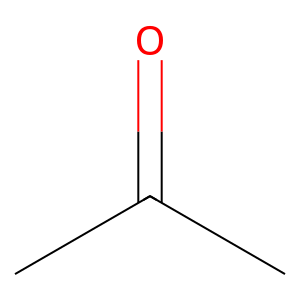

In [107]:
linker03 = Chem.MolFromSmarts('c-C(=O)-C')
Draw.MolToImage(linker03)

In [108]:
all_structures["sub_link03"] = all_structures["mol"].apply(lambda x: x.HasSubstructMatch(linker03))

sources = all_structures["source"].unique()
print("Procento molekul obsahujících keton linker:")
for source in sources:
    df_source = all_structures[all_structures["source"] == source]
    procento = df_source["sub_link03"].mean() * 100
    print(f" - {source}: {procento:.2f} %")

Procento molekul obsahujících keton linker:
 - H3: 0.78 %
 - mtor: 2.48 %
 - zinc: 0.78 %
 - drugbank: 2.47 %


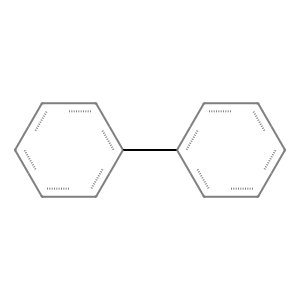

In [109]:
core01 = Chem.MolFromSmarts('c1ccccc1-c2ccccc2')
Draw.MolToImage(core01)

In [110]:
all_structures["sub_bifenyl"] = all_structures["mol"].apply(lambda x: x.HasSubstructMatch(core01))

sources = all_structures["source"].unique()
print("Procento molekul obsahujících bifenyl (core):")
for source in sources:
    df_source = all_structures[all_structures["source"] == source]
    procento = df_source["sub_bifenyl"].mean() * 100
    print(f" - {source}: {procento:.2f} %")

Procento molekul obsahujících bifenyl (core):
 - H3: 5.28 %
 - mtor: 0.85 %
 - zinc: 0.18 %
 - drugbank: 2.46 %


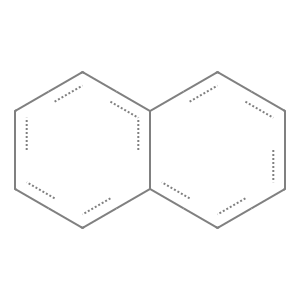

In [111]:
core02 = Chem.MolFromSmarts('c1ccc2ccccc2c1')
Draw.MolToImage(core02)

In [112]:
all_structures["sub_naftalen"] = all_structures["mol"].apply(lambda x: x.HasSubstructMatch(core02))

sources = all_structures["source"].unique()
print("Procento molekul obsahujících indan (core):")
for source in sources:
    df_source = all_structures[all_structures["source"] == source]
    procento = df_source["sub_naftalen"].mean() * 100
    print(f" - {source}: {procento:.2f} %")

Procento molekul obsahujících indan (core):
 - H3: 1.76 %
 - mtor: 0.52 %
 - zinc: 0.18 %
 - drugbank: 2.60 %


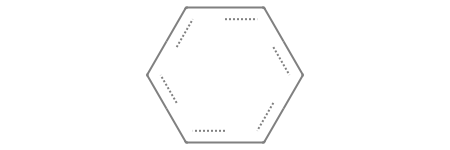

In [113]:
benzene = Chem.MolFromSmarts("c1ccccc1")
benzene

In [114]:
all_structures["sub_benzen"] = all_structures["mol"].apply(lambda x: x.HasSubstructMatch(benzene))

sources = all_structures["source"].unique()
print("Procento molekul obsahujících benzen:")
for source in sources:
    df_source = all_structures[all_structures["source"] == source]
    procento = df_source["sub_benzen"].mean() * 100
    print(f" - {source}: {procento:.2f} %")

Procento molekul obsahujících benzen:
 - H3: 81.12 %
 - mtor: 80.00 %
 - zinc: 32.84 %
 - drugbank: 60.22 %


In [115]:
all_structures

,Smiles,mol,MolecularWeight,LogP,HBD,HBA,vHBA,vHBD,vMW,vLogP,...,source,sub_imidazol,sub_piperidine,sub_pyrrolidine,sub_link,sub_link02,sub_link03,sub_bifenyl,sub_naftalen,sub_benzen
CHEMBL1222870,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2CCN(C3CCCCC3)CC2)cc1,<rdkit.Chem.rdchem.Mol object at 0x344e82340>,434.563,3.90020,0,5,False,False,False,False,...,H3,False,False,False,False,False,False,False,False,True
CHEMBL1223009,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2C[C@H]3CC[C@@H](C2...,<rdkit.Chem.rdchem.Mol object at 0x344e824d0>,432.547,3.65100,0,5,False,False,False,False,...,H3,False,False,True,False,False,False,False,False,True
CHEMBL1270059,C[C@@H]1C[C@@](O)(CCc2cccc3ccccc23)[C@@H](C)CN1C,<rdkit.Chem.rdchem.Mol object at 0x344e818a0>,297.442,3.86360,1,2,False,False,False,False,...,H3,False,True,False,False,False,False,False,True,True
CHEMBL2403548,Cc1cc(N2CC[C@H](N3CCC[C@H]3C)C2)ccc1NC(=O)c1cc...,<rdkit.Chem.rdchem.Mol object at 0x344e82570>,395.522,4.75784,1,3,False,False,False,False,...,H3,False,False,True,False,False,False,False,False,True
CHEMBL6005581,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OC2C...,<rdkit.Chem.rdchem.Mol object at 0x344e82ed0>,586.627,6.06312,0,5,False,False,True,True,...,H3,False,True,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DB13154,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0040>,128.558,2.04560,1,1,False,False,False,False,...,drugbank,False,False,False,False,False,False,False,False,True
DB13155,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac02c0>,340.284,-1.32270,5,9,False,False,False,False,...,drugbank,False,False,False,True,False,False,False,False,True
DB13156,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0270>,1115.249,1.54710,13,19,True,True,True,False,...,drugbank,True,False,False,True,False,False,False,False,True
DB13157,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0450>,330.422,-0.00030,0,5,False,False,False,False,...,drugbank,False,False,False,True,False,False,False,False,False


In [116]:
long_structures = all_structures.melt(id_vars = ['source'], value_vars=["sub_imidazol", "sub_piperidine", "sub_pyrrolidine", "sub_link", "sub_link02", "sub_bifenyl", "sub_naftalen", "sub_link03", "sub_benzen"])  
long_structures

,source,variable,value
0,H3,sub_imidazol,False
1,H3,sub_imidazol,False
2,H3,sub_imidazol,False
3,H3,sub_imidazol,False
4,H3,sub_imidazol,False
...,...,...,...
179257,drugbank,sub_benzen,True
179258,drugbank,sub_benzen,True
179259,drugbank,sub_benzen,True
179260,drugbank,sub_benzen,False


Text(0.5, 1.0, 'Zastoupení podstruktur podle zdroje')

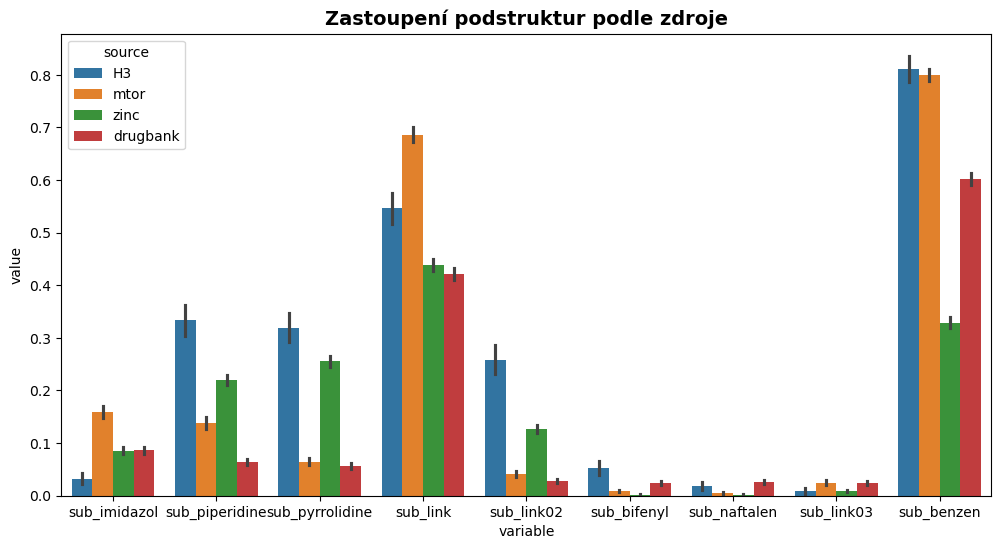

In [117]:
plt.figure(figsize=(12, 6))
sns.barplot(data=long_structures,x="variable", y="value", hue = "source")
plt.title("Zastoupení podstruktur podle zdroje", fontsize=14, fontweight="bold")

### PAINS
PAINS je zkratka pro Pan-assay interference compounds - chemické sloučeniny, které často dávají FP výsledky při provádění assays/screeningu.

In [123]:
pains = {}
with open("/Users/simona/Dev/cdd2026/data/pains/p_l15.txt") as soubor:
    for řádka in soubor:
        smart, name = řádka.strip().split("\t")
        pains[name.replace('<regId="',"").replace('">','')] = Chem.MolFromSmarts(smart)
with open("/Users/simona/Dev/cdd2026/data/pains/p_m150.txt") as soubor:
    for řádka in soubor:
        smart, name = řádka.strip().split("\t")
        pains[name.replace('<regId="',"").replace('">','')] = Chem.MolFromSmarts(smart)

In [124]:
type(pains)

dict

In [125]:
def identify_pains(mol):
    if mol is None:
        return ["Invalid"]
    
    found_pains = []
    for name, pattern in pains.items():
        if mol.HasSubstructMatch(pattern):
            found_pains.append(name) 
            
    return found_pains if found_pains else []

In [126]:
all_structures["pains"] = all_structures["mol"].apply(identify_pains)

In [127]:
all_structures["pains_count"] = all_structures["pains"].str.len()
all_structures

,Smiles,mol,MolecularWeight,LogP,HBD,HBA,vHBA,vHBD,vMW,vLogP,...,sub_piperidine,sub_pyrrolidine,sub_link,sub_link02,sub_link03,sub_bifenyl,sub_naftalen,sub_benzen,pains,pains_count
CHEMBL1222870,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2CCN(C3CCCCC3)CC2)cc1,<rdkit.Chem.rdchem.Mol object at 0x344e82340>,434.563,3.90020,0,5,False,False,False,False,...,False,False,False,False,False,False,False,True,[],0
CHEMBL1223009,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2C[C@H]3CC[C@@H](C2...,<rdkit.Chem.rdchem.Mol object at 0x344e824d0>,432.547,3.65100,0,5,False,False,False,False,...,False,True,False,False,False,False,False,True,[],0
CHEMBL1270059,C[C@@H]1C[C@@](O)(CCc2cccc3ccccc23)[C@@H](C)CN1C,<rdkit.Chem.rdchem.Mol object at 0x344e818a0>,297.442,3.86360,1,2,False,False,False,False,...,True,False,False,False,False,False,True,True,[],0
CHEMBL2403548,Cc1cc(N2CC[C@H](N3CCC[C@H]3C)C2)ccc1NC(=O)c1cc...,<rdkit.Chem.rdchem.Mol object at 0x344e82570>,395.522,4.75784,1,3,False,False,False,False,...,False,True,False,False,False,False,False,True,[],0
CHEMBL6005581,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OC2C...,<rdkit.Chem.rdchem.Mol object at 0x344e82ed0>,586.627,6.06312,0,5,False,False,True,True,...,True,False,True,False,False,False,False,True,[],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DB13154,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0040>,128.558,2.04560,1,1,False,False,False,False,...,False,False,False,False,False,False,False,True,[],0
DB13155,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac02c0>,340.284,-1.32270,5,9,False,False,False,False,...,False,False,True,False,False,False,False,True,[],0
DB13156,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0270>,1115.249,1.54710,13,19,True,True,True,False,...,False,False,True,False,False,False,False,True,[],0
DB13157,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0450>,330.422,-0.00030,0,5,False,False,False,False,...,False,False,True,False,False,False,False,False,[],0


Text(0.5, 0, '')

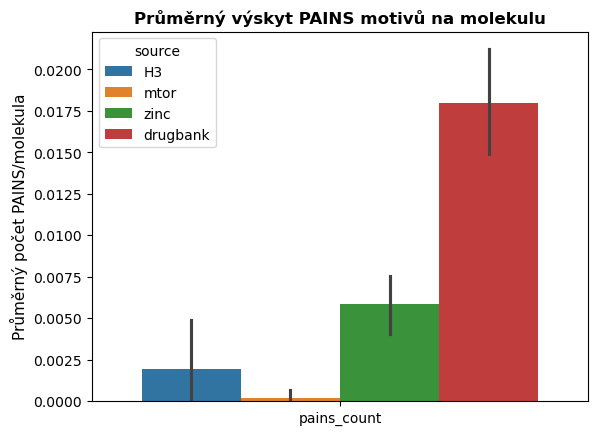

In [128]:
sns.barplot(data=all_structures.melt(["source"],["pains_count"]), x="variable", y="value", hue="source")
plt.title("Průměrný výskyt PAINS motivů na molekulu", fontsize=12, fontweight="bold")
plt.ylabel("Průměrný počet PAINS/molekula", fontsize=11)
plt.xlabel("")

In [129]:
top_pains_H3 = all_structures[all_structures["source"] == "H3"].sort_values("pains_count", ascending=False).head()[["Smiles","pains_count", "pains", "mol"]]
top_pains_H3

,Smiles,pains_count,pains,mol
CHEMBL1223516,c1ccc(Cn2nnnc2C(c2ccc(N3CCOCC3)cc2)N2CCCN(C3CC...,1,[anil_di_alk_D(198)],<rdkit.Chem.rdchem.Mol object at 0x344ea9760>
CHEMBL1222434,CN1CCN(c2ccc(C(c3nnnn3Cc3ccccc3)N3CCCN(C4CCC4)...,1,[anil_di_alk_D(198)],<rdkit.Chem.rdchem.Mol object at 0x344eb0c20>
CHEMBL1222870,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2CCN(C3CCCCC3)CC2)cc1,0,[],<rdkit.Chem.rdchem.Mol object at 0x344e82340>
CHEMBL6018283,CN1CCCC2CN(c3nc4ncc(Cl)cc4n4cnnc34)CC21,0,[],<rdkit.Chem.rdchem.Mol object at 0x344eb7740>
CHEMBL5924703,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OC2C...,0,[],<rdkit.Chem.rdchem.Mol object at 0x344eb7560>


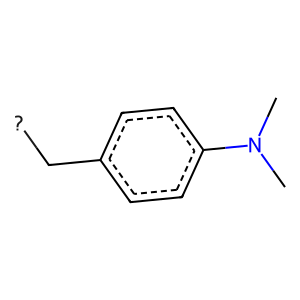

In [130]:
Draw.MolToImage(pains['anil_di_alk_D(198)'])

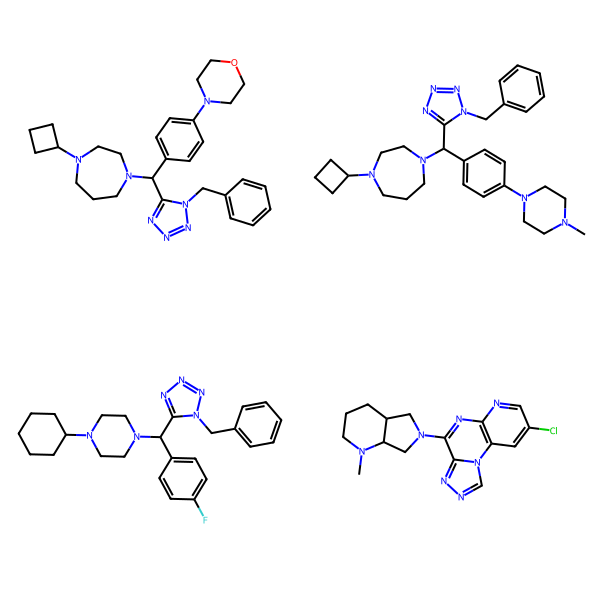

In [131]:
mols = top_pains_H3["mol"].head(4).tolist()
Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(300, 300))

### Fingerprinty a podobnosti

In [132]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3)

In [133]:
# sparse fingerprinty
all_structures["ecfp6"] = all_structures["mol"].apply(lambda x: morgan_gen.GetSparseCountFingerprint(x) if x is not None else None)

In [134]:
all_structures["bit_counts_Morgan"] = all_structures["ecfp6"].apply(lambda x: x.GetNonzeroElements() if x is not None else {})

In [135]:
all_structures

,Smiles,mol,MolecularWeight,LogP,HBD,HBA,vHBA,vHBD,vMW,vLogP,...,sub_link,sub_link02,sub_link03,sub_bifenyl,sub_naftalen,sub_benzen,pains,pains_count,ecfp6,bit_counts_Morgan
CHEMBL1222870,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2CCN(C3CCCCC3)CC2)cc1,<rdkit.Chem.rdchem.Mol object at 0x344e82340>,434.563,3.90020,0,5,False,False,False,False,...,False,False,False,False,False,True,[],0,<rdkit.DataStructs.cDataStructs.ULongSparseInt...,"{19852674: 2, 57223098: 1, 98513984: 3, 118059..."
CHEMBL1223009,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2C[C@H]3CC[C@@H](C2...,<rdkit.Chem.rdchem.Mol object at 0x344e824d0>,432.547,3.65100,0,5,False,False,False,False,...,False,False,False,False,False,True,[],0,<rdkit.DataStructs.cDataStructs.ULongSparseInt...,"{19852674: 2, 57223098: 1, 98513984: 3, 118059..."
CHEMBL1270059,C[C@@H]1C[C@@](O)(CCc2cccc3ccccc23)[C@@H](C)CN1C,<rdkit.Chem.rdchem.Mol object at 0x344e818a0>,297.442,3.86360,1,2,False,False,False,False,...,False,False,False,False,True,True,[],0,<rdkit.DataStructs.cDataStructs.ULongSparseInt...,"{3624155: 1, 69001947: 1, 98513984: 3, 1366778..."
CHEMBL2403548,Cc1cc(N2CC[C@H](N3CCC[C@H]3C)C2)ccc1NC(=O)c1cc...,<rdkit.Chem.rdchem.Mol object at 0x344e82570>,395.522,4.75784,1,3,False,False,False,False,...,False,False,False,False,False,True,[],0,<rdkit.DataStructs.cDataStructs.ULongSparseInt...,"{19852674: 1, 92620239: 1, 124611947: 1, 13528..."
CHEMBL6005581,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OC2C...,<rdkit.Chem.rdchem.Mol object at 0x344e82ed0>,586.627,6.06312,0,5,False,False,True,True,...,True,False,False,False,False,True,[],0,<rdkit.DataStructs.cDataStructs.ULongSparseInt...,"{10565946: 1, 204805922: 1, 266640374: 1, 3314..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DB13154,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0040>,128.558,2.04560,1,1,False,False,False,False,...,False,False,False,False,False,True,[],0,<rdkit.DataStructs.cDataStructs.ULongSparseInt...,"{26234434: 1, 285715910: 1, 859799282: 1, 8646..."
DB13155,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac02c0>,340.284,-1.32270,5,9,False,False,False,False,...,True,False,False,False,False,True,[],0,<rdkit.DataStructs.cDataStructs.ULongSparseInt...,"{8098702: 1, 10565946: 1, 13251412: 1, 2623443..."
DB13156,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0270>,1115.249,1.54710,13,19,True,True,True,False,...,True,False,False,False,False,True,[],0,<rdkit.DataStructs.cDataStructs.ULongSparseInt...,"{10565946: 1, 24535115: 1, 42183873: 1, 433570..."
DB13157,NaN,<rdkit.Chem.rdchem.Mol object at 0x35aac0450>,330.422,-0.00030,0,5,False,False,False,False,...,True,False,False,False,False,False,[],0,<rdkit.DataStructs.cDataStructs.ULongSparseInt...,"{154118180: 1, 161963127: 7, 353299074: 1, 388..."


In [136]:
def aggregate_source_bits(series):
    total_counts = Counter()
    for bit_dict in series:
        # Sčítáme pouze řádky, které jsou skutečně slovníky
        if isinstance(bit_dict, dict):
            total_counts.update(bit_dict)
    return dict(total_counts)

source_fragment_counts = all_structures.groupby("source")["bit_counts_Morgan"].apply(aggregate_source_bits)

In [137]:
for source in source_fragment_counts.index.get_level_values(0).unique():
    data = source_fragment_counts.xs(source, level=0)
    data = data[data > 0]
    data_sorted = data.sort_values(ascending=False)

    unikatni = len(data_sorted)
    
    print(f"--- Zdroj: {source} (Unikátních fragmentů: {unikatni}) ---")
    top5 = data_sorted.head(5)
    
    for fragment_id, celkovy_vyskyt in top5.items():
        print(f"ID fragmentu: {int(fragment_id):>15} | Celkový výskyt: {int(celkovy_vyskyt)}x")
        
    print()

--- Zdroj: H3 (Unikátních fragmentů: 6601) ---
ID fragmentu:      3218693969 | Celkový výskyt: 5929x
ID fragmentu:      2968968094 | Celkový výskyt: 5587x
ID fragmentu:      3217380708 | Celkový výskyt: 4748x
ID fragmentu:       951226070 | Celkový výskyt: 4038x
ID fragmentu:      2803848648 | Celkový výskyt: 2201x

--- Zdroj: drugbank (Unikátních fragmentů: 82913) ---
ID fragmentu:      3218693969 | Celkový výskyt: 30546x
ID fragmentu:      3217380708 | Celkový výskyt: 26560x
ID fragmentu:       951226070 | Celkový výskyt: 16001x
ID fragmentu:      2245384272 | Celkový výskyt: 15601x
ID fragmentu:       864942730 | Celkový výskyt: 12177x

--- Zdroj: mtor (Unikátních fragmentů: 20296) ---
ID fragmentu:      3217380708 | Celkový výskyt: 35934x
ID fragmentu:      3218693969 | Celkový výskyt: 30596x
ID fragmentu:      2968968094 | Celkový výskyt: 18603x
ID fragmentu:       951226070 | Celkový výskyt: 17247x
ID fragmentu:      2041434490 | Celkový výskyt: 14208x

--- Zdroj: zinc (Unikátníc

Nalezené molekuly obsahující bit 2803848648:
--- CHEMBL1222870 (Zdroj: H3) ---


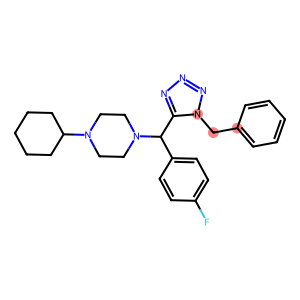



--- CHEMBL2403548 (Zdroj: H3) ---


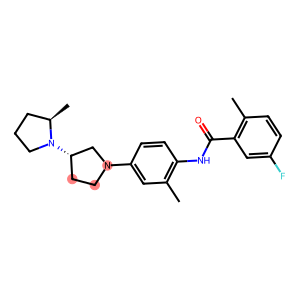



--- CHEMBL6005581 (Zdroj: H3) ---


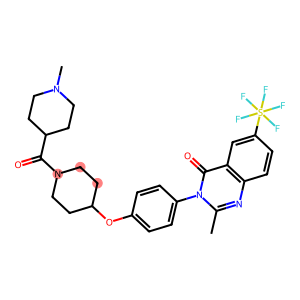



--- CHEMBL3753901 (Zdroj: H3) ---


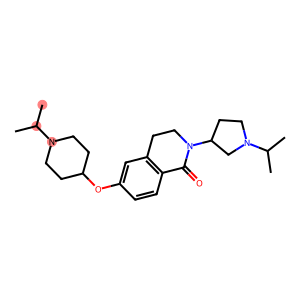



--- CHEMBL490195 (Zdroj: H3) ---


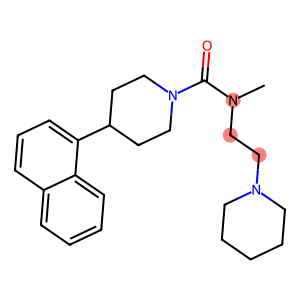

In [138]:
bit = 2803848648  
n_mol = 5


matches = all_structures[all_structures["bit_counts_Morgan"].apply(
    lambda x: int(bit) in [int(k) for k in x.keys()] if isinstance(x, dict) else False
)].head(n_mol)

if matches.empty:
    print(f"Chyba: Bit {bit} v tabulce vůbec není.")
else:
    print(f"Nalezené molekuly obsahující bit {bit}:")
    for idx, row in matches.iterrows():
        target_mol = row["mol"]
        target_source = row["source"]
        
        additional_info = rdFingerprintGenerator.AdditionalOutput()
        additional_info.AllocateBitInfoMap()
        morgan_gen.GetSparseCountFingerprint(target_mol, additionalOutput=additional_info)
        bit_info = {int(k): v for k, v in additional_info.GetBitInfoMap().items()}
        
        if bit in bit_info:
            center_atom, radius = bit_info[bit][0]
            
            if radius == 0:
                atoms = [center_atom]
            else:
                env = Chem.FindAtomEnvironmentOfRadiusN(target_mol, radius, center_atom)
                submol = Chem.PathToSubmol(target_mol, env)
                atoms = list(target_mol.GetSubstructMatch(submol))
            
            print(f"--- {idx} (Zdroj: {target_source}) ---")
            img = Draw.MolToImage(target_mol, size=(300, 300), highlightAtoms=atoms)
            display(img)
            print("\n") 

### Pitolisant

Zkusíme vyhledat [pitolisant](https://www.ebi.ac.uk/chembl/explore/compound/CHEMBL462605) jako query vzhledem k datasetu látek vázajících se na H3 receptor. Jde o jediného schváleného selektivního antagonistu H3 receptoru, který se reálně používá v medicíně k léčbě narkolepsie

In [139]:
pitolisant = Chem.MolFromSmiles('Clc1ccc(CCCOCCCN2CCCCC2)cc1')
ecfp6_query = morgan_gen.GetSparseCountFingerprint(pitolisant)

In [141]:
from rdkit import DataStructs

similarity = []
for index, row in all_structures[all_structures["source"]=="H3"].iterrows():
    similarity.append((index, DataStructs.TanimotoSimilarity(row["ecfp6"], ecfp6_query)))

In [142]:
similarity_sorted = sorted(similarity, key=lambda x: x[1], reverse=True)
similarity_sorted[:10]

[('CHEMBL462605', 1.0),
 ('CHEMBL462605', 1.0),
 ('CHEMBL462605', 1.0),
 ('CHEMBL2441949', 0.5742574257425742),
 ('CHEMBL2441947', 0.5742574257425742),
 ('CHEMBL2441941', 0.5742574257425742),
 ('CHEMBL2441942', 0.5523809523809524),
 ('CHEMBL2441940', 0.5346534653465347),
 ('CHEMBL2441935', 0.49504950495049505),
 ('CHEMBL2441938', 0.4803921568627451)]

In [143]:
len(all_structures)

19918

In [144]:
all_structures.index.nunique()

19284

Zajímavé je, že látek unikatních je tedy jen 818 v datasetu pro H3 receptor.

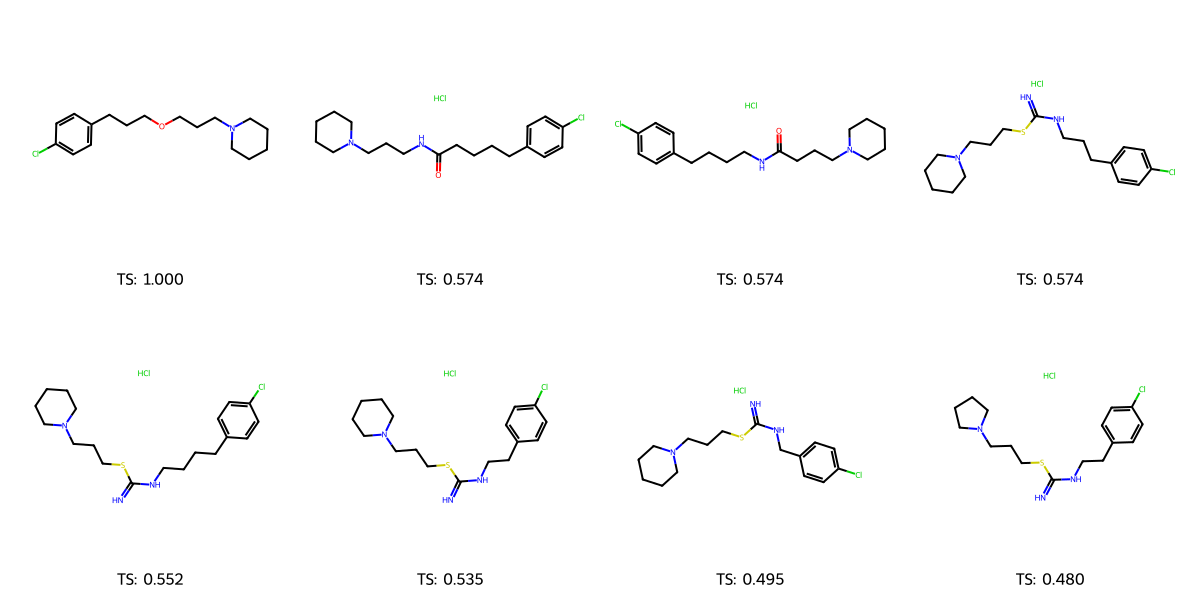

In [145]:
top_hits = similarity_sorted[2:10:1]

Draw.MolsToGridImage(
    [all_structures.loc[idx, "mol"].values[0] if hasattr(all_structures.loc[idx, "mol"], "values") else all_structures.loc[idx, "mol"] for idx, s in top_hits], 
    molsPerRow=4, 
    subImgSize=(300, 300),
    legends=[f"TS: {s:.3f}" for idx, s in top_hits]
)

### Scaffold analysis
V této části kódu odstraňujeme z molekul postranní řetězce a zjišťujeme jejich základní strukturní kostru, neboli tzv. Murcko scaffold. Následně počítáme, kolik unikátních koster se nachází v jednotlivých datasetech a kolik molekul v průměru sdílí stejnou kostru.

In [146]:
def get_scaffold(input_molecule):
    if input_molecule is None:
        return None
    try:
        scaff = MurckoScaffold.MakeScaffoldGeneric(input_molecule)
    except ValueError:
        return None
    scaff = MurckoScaffold.GetScaffoldForMol(scaff)
    return scaff

In [147]:
all_structures["scaffold"] = all_structures["mol"].apply(get_scaffold)
all_structures["scaffold_smiles"] = all_structures["scaffold"].apply(
    lambda x: Chem.MolToSmiles(x) if x is not None else None
)
all_structures[["source", "scaffold_smiles"]].head(20)

,source,scaffold_smiles
CHEMBL1222870,H3,C1CCC(CC2CCCC2C(C2CCCCC2)C2CCC(C3CCCCC3)CC2)CC1
CHEMBL1223009,H3,C1CCC(CC2CCCC2C(C2CCCCC2)C2CC3CCC(C2)C3C2CCC2)CC1
CHEMBL1270059,H3,C1CCC(CCC2CCCC3CCCCC32)CC1
CHEMBL2403548,H3,C1CCC(CCC2CCC(C3CCC(C4CCCC4)C3)CC2)CC1
CHEMBL6005581,H3,NaN
CHEMBL3753901,H3,C1CCC(CC2CCC3CC(C4CCCC4)CCC3C2)CC1
CHEMBL490195,H3,C1CCC(CCCCC2CCC(C3CCCC4CCCCC43)CC2)CC1
CHEMBL489589,H3,C1CCC(CCCCC2CCC(C3CCCCC3)CC2)CC1
CHEMBL522117,H3,C1CCC(CCCCC2CCC3(CCCC4CCCCC43)CC2)CC1
CHEMBL476963,H3,C1CCC(CCCCC2CCC3(CC2)CCC2CCCCC23)CC1


In [148]:
scaffolds_by_source = {}
for src in all_structures["source"].unique():
    d = defaultdict(list)
    sub = all_structures[(all_structures["source"] == src) &
                        (all_structures["scaffold_smiles"].notna())]
    for idx, scaff in zip(sub.index, sub["scaffold_smiles"]):
        d[scaff].append(idx)
    scaffolds_by_source[src] = d
    print(f"{src:10s}: {len(sub)} molekul, {len(d)} unikátních scaffoldů, "
          f"průměrně {len(sub)/len(d):.2f} molekul/scaffold")

H3        : 914 molekul, 228 unikátních scaffoldů, průměrně 4.01 molekul/scaffold
mtor      : 4596 molekul, 648 unikátních scaffoldů, průměrně 7.09 molekul/scaffold
zinc      : 7179 molekul, 3621 unikátních scaffoldů, průměrně 1.98 molekul/scaffold
drugbank  : 7099 molekul, 1558 unikátních scaffoldů, průměrně 4.56 molekul/scaffold


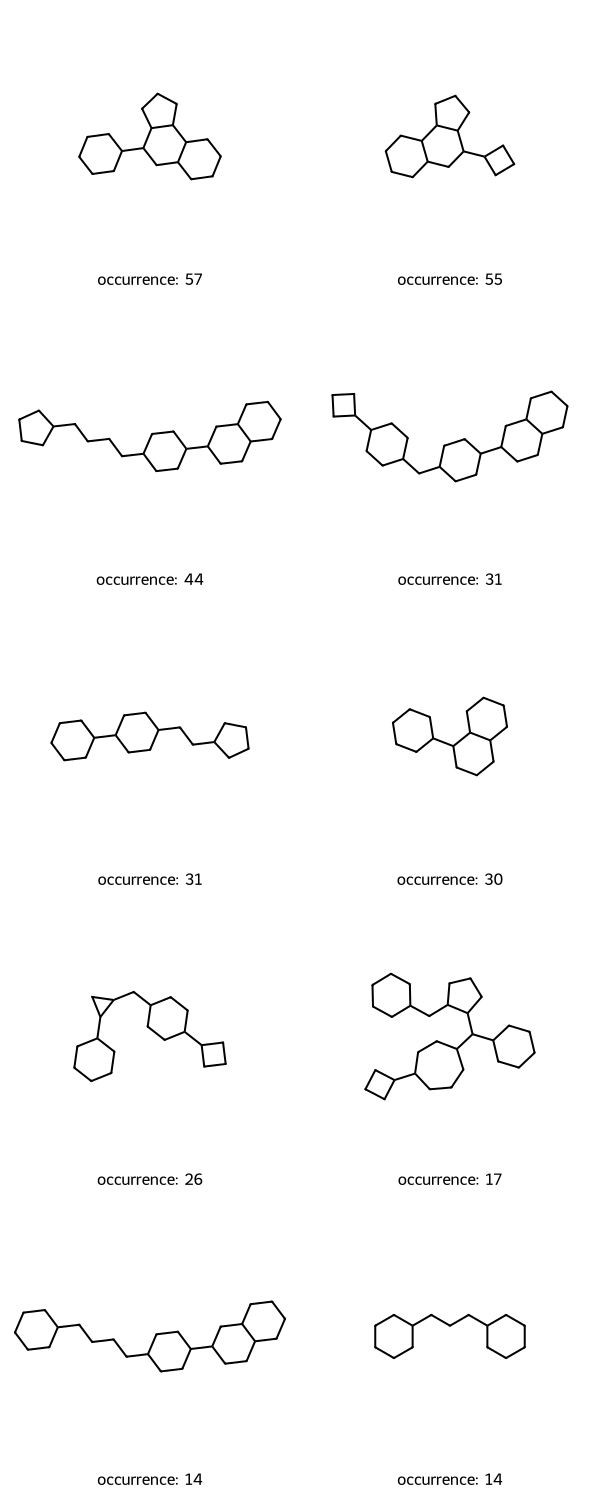

In [149]:
def top_scaffolds(scaffold_dict, n=10):
    sorted_list = sorted(
        [(scaff, len(idxs)) for scaff, idxs in scaffold_dict.items()],
        key=lambda x: x[1], reverse=True
    )
    return sorted_list[:n]

top_h3 = top_scaffolds(scaffolds_by_source["H3"])
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for s, _ in top_h3],
    molsPerRow=2, subImgSize=(300, 300),
    legends=[f"occurrence: {c}" for _, c in top_h3]
)

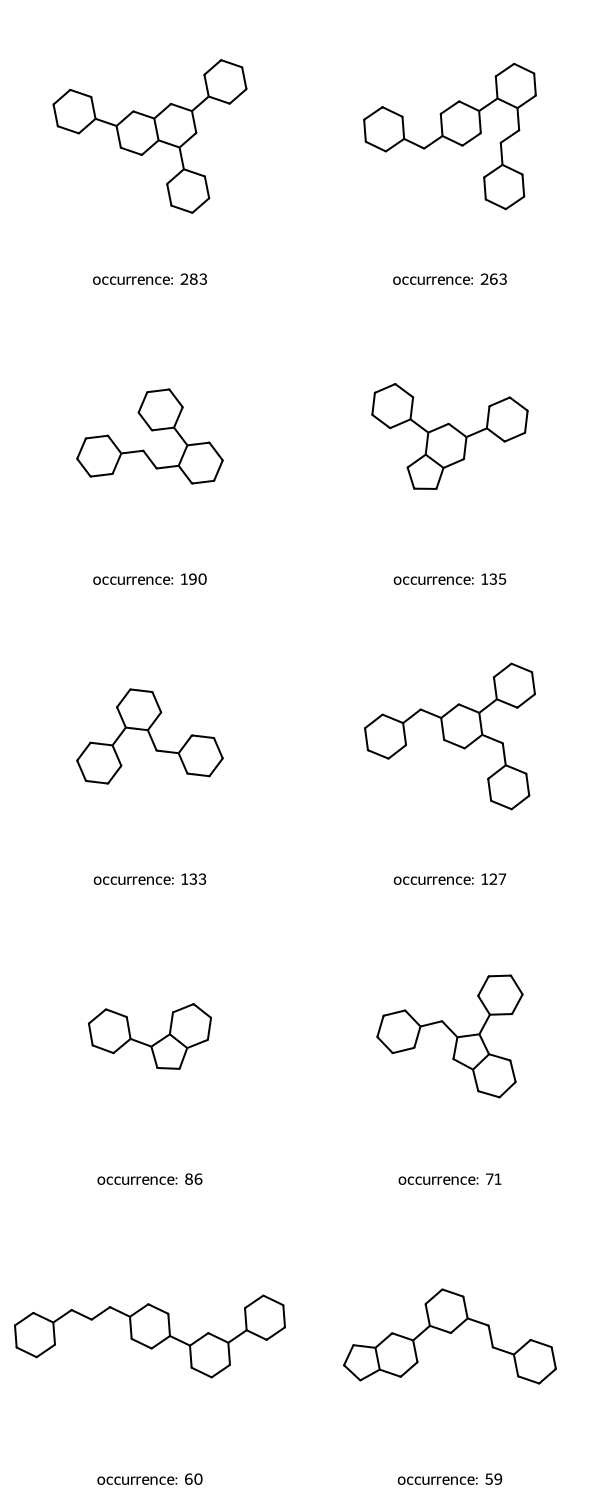

In [150]:
top_mtor = top_scaffolds(scaffolds_by_source["mtor"])
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for s, _ in top_mtor],
    molsPerRow=2, subImgSize=(300, 300),
    legends=[f"occurrence: {c}" for _, c in top_mtor]
)

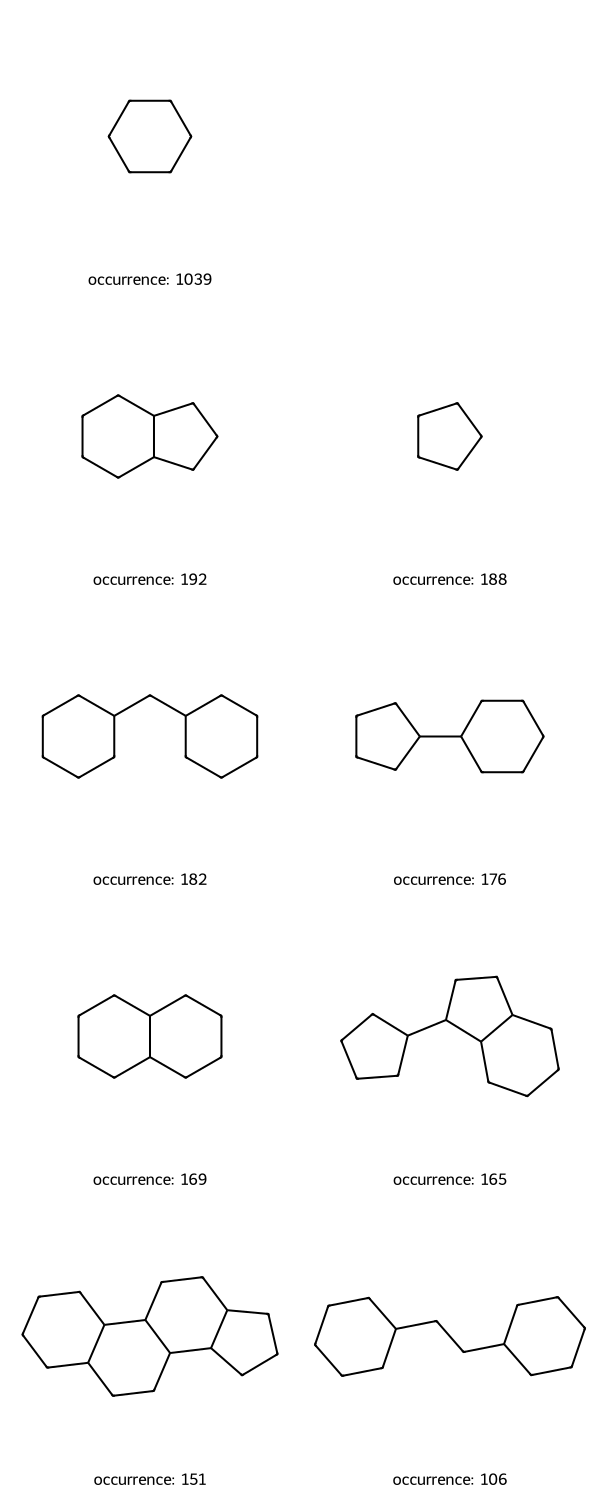

In [151]:
top_drugbank = top_scaffolds(scaffolds_by_source["drugbank"])
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for s, _ in top_drugbank],
    molsPerRow=2, subImgSize=(300, 300),
    legends=[f"occurrence: {c}" for _, c in top_drugbank]
)

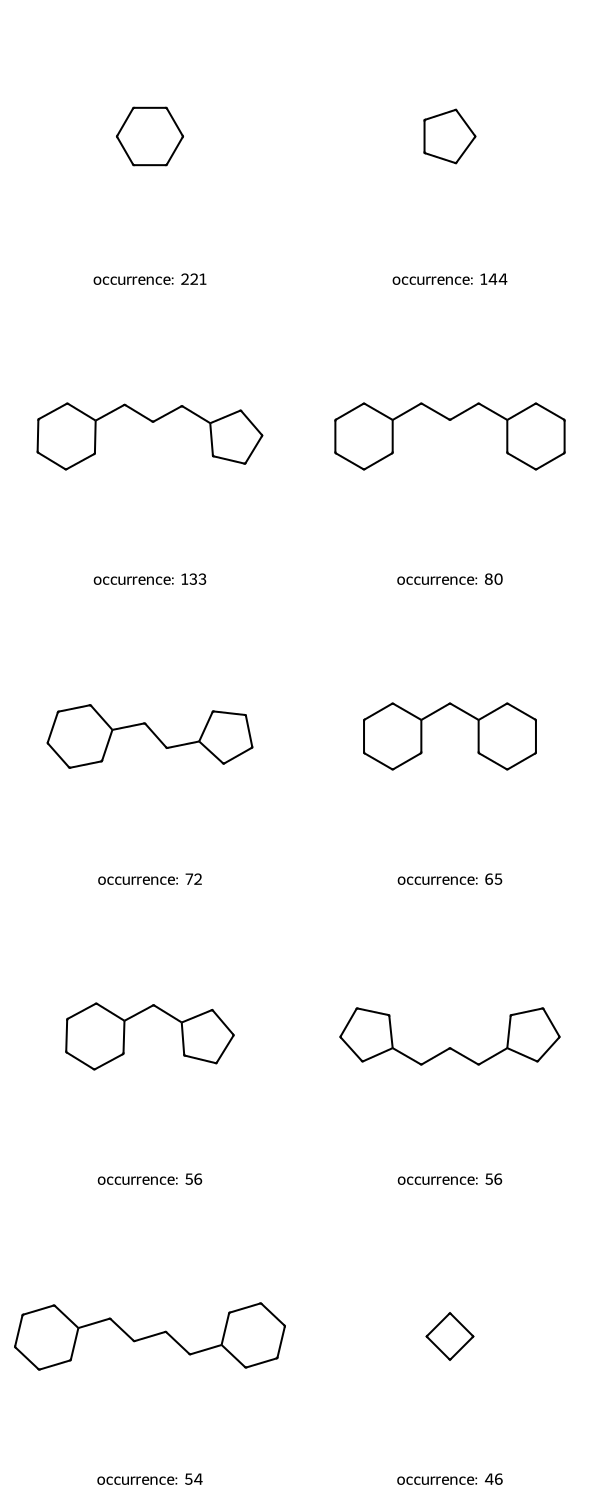

In [152]:
top_zinc = top_scaffolds(scaffolds_by_source["zinc"])
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for s, _ in top_zinc],
    molsPerRow=2, subImgSize=(300, 300),
    legends=[f"occurrence: {c}" for _, c in top_zinc]
)

### Vizualizace chemického prostoru pomocí PCA (MQN deskriptory)
Abychom zjistili, zda se molekuly z různých zdrojů vyskytují ve stejném "chemickém prostoru", použijeme metodu hlavních komponent (PCA). Ta umí vícerozměrná data - v našem případě MQN deskriptory kódující např. počty atomů, vazeb, cyklů a funkčních skupin - zredukovat na 2D projekci.

In [153]:
from rdkit.Chem import rdMolDescriptors

morgan_bit_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
all_structures["fp_bit"] = all_structures["mol"].apply(
    lambda x: morgan_bit_gen.GetFingerprint(x) if x is not None else None
)

# MQN deskriptory (42 hodnot)
mqn_cols = [f"MQN_{i}" for i in range(1, 43)]
mqn_values = [rdMolDescriptors.MQNs_(m) if m is not None else [0]*42
              for m in all_structures["mol"]]
for i, col in enumerate(mqn_cols):
    all_structures[col] = [v[i] for v in mqn_values]

all_structures[mqn_cols].head()

,MQN_1,MQN_2,MQN_3,MQN_4,MQN_5,MQN_6,MQN_7,MQN_8,MQN_9,MQN_10,...,MQN_33,MQN_34,MQN_35,MQN_36,MQN_37,MQN_38,MQN_39,MQN_40,MQN_41,MQN_42
CHEMBL1222870,25,1,0,0,0,0,0,0,6,0,...,0,0,1,4,0,0,0,0,0,0
CHEMBL1223009,25,1,0,0,0,0,0,0,6,0,...,0,1,2,3,0,0,0,0,3,2
CHEMBL1270059,20,0,0,0,0,0,0,0,1,1,...,0,0,0,3,0,0,0,0,2,1
CHEMBL2403548,24,1,0,0,0,0,0,1,2,1,...,0,0,2,2,0,0,0,0,0,0
CHEMBL6005581,27,5,0,0,0,1,0,0,4,3,...,0,0,0,5,0,0,0,0,2,1


In [154]:
pca = decomposition.PCA(n_components=2)
pca_coords = pca.fit_transform(all_structures[mqn_cols])
all_structures["pca_x"] = pca_coords[:, 0]
all_structures["pca_y"] = pca_coords[:, 1]

print(f"Vysvětlený rozptyl prvních 2 komponent: "
      f"{pca.explained_variance_ratio_.sum()*100:.1f} %")

Vysvětlený rozptyl prvních 2 komponent: 84.0 %


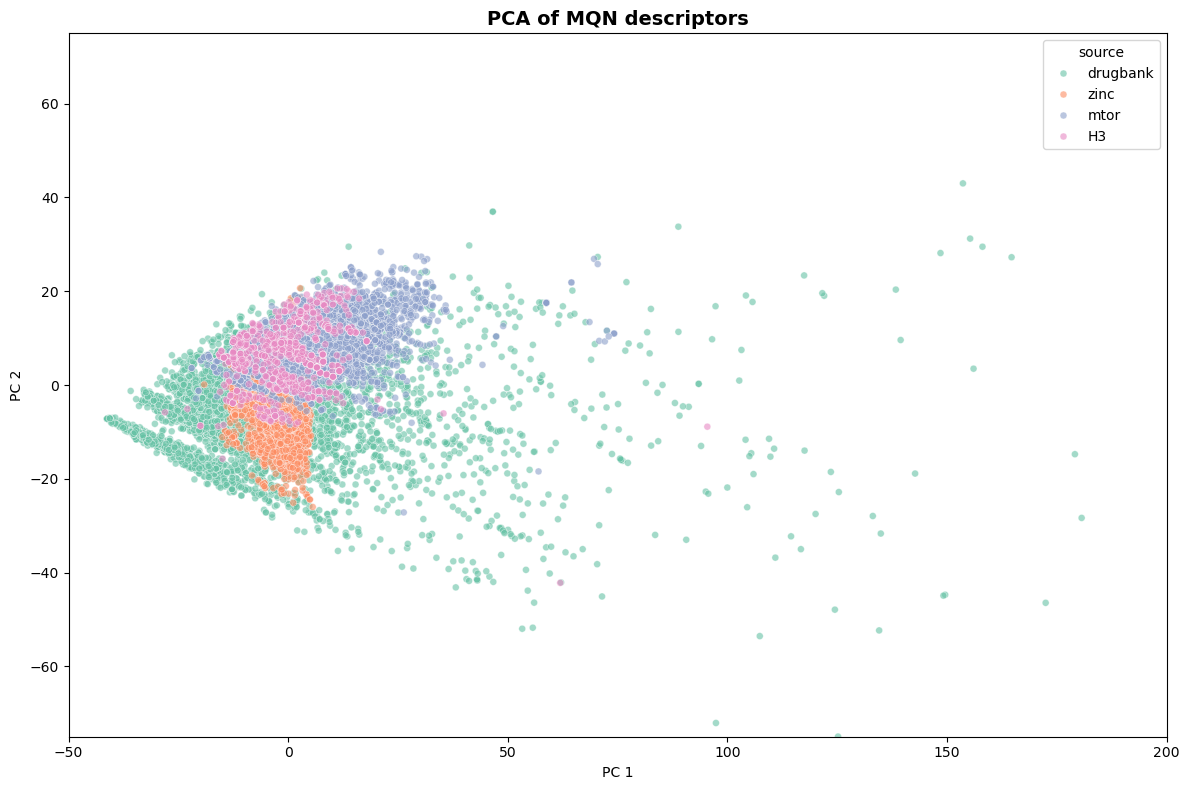

In [155]:
order = ["drugbank", "zinc", "mtor", "H3"]
all_structures_sorted = pd.concat([
    all_structures[all_structures["source"] == src] 
    for src in order
])

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=all_structures_sorted, x="pca_x", y="pca_y",
    hue="source", palette="Set2", alpha=0.6, s=25, ax=ax
)
ax.set_title("PCA of MQN descriptors",
             fontsize=14, fontweight="bold")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_xlim(-50, 200)
ax.set_ylim(-75, 75)
plt.tight_layout()
plt.show()

Tento *scatter plot* představuje 2D projekci vícerozměrného chemického prostoru pomocí analýzy hlavních komponent (PCA). Původní data byla zredukována do dvou hlavních os (PC1 a PC2). Tyto dvě osy zachycují největší možnou část rozptylu napříč všemi molekulami.

**ZINC a DrugBank** Rozsáhlé datasety ZINC (koupitelné látky) a DrugBank (schválená léčiva).

**H3 a mTOR ligandy** Body reprezentující aktivní ligandy pro cíle H3 a mTOR.
* H3 ligandy tvoří kompaktní shluk, který se překrývá zejména s DrugBank a mTOR, méně se ZINC.

### Klastrování molekul pomocí t-SNE (Morgan Fingerprints)
Zatímco PCA nad MQN poskytuje jen "hrubý obrys", pro detailní analýzu podobnosti jsme použili Morgan fingerprinty (kódující kruhové chemické okolí atomů). Kód nejprve převede bitové vektory na matici vzdáleností pomocí metriky Jaccard (v chemoinformatice známá jako Tanimoto vzdálenost, standard pro určování 2D chemické podobnosti). Na tuto matici následně nasadíme algoritmus t-SNE, což je nelineární redukční metoda pro hledání lokálních shluků (klastrů).

In [156]:
from scipy.spatial import distance
import numpy as np
from rdkit import DataStructs

# Převod RDKit fingerprintů na numpy array
# Pokud je fp None použijeme nulový vektor
fp_list = []
for fp in all_structures["fp_bit"]:
    arr = np.zeros((1024,), dtype=int)
    if fp is not None:
        DataStructs.ConvertToNumpyArray(fp, arr)
    fp_list.append(arr)
fp_array = np.array(fp_list)

# Spočítáme Jaccard distance (= 1 - Tanimoto similarity)
sparse_mat = distance.pdist(fp_array, metric="jaccard")
dist_mat = distance.squareform(sparse_mat)
print("Distance matrix shape:", dist_mat.shape)

Distance matrix shape: (19918, 19918)


In [157]:
from sklearn import manifold

tsne = manifold.TSNE(n_components=2, metric="precomputed",
                      init="random", random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(dist_mat)
all_structures["tsne_x"] = X_tsne[:, 0]
all_structures["tsne_y"] = X_tsne[:, 1]

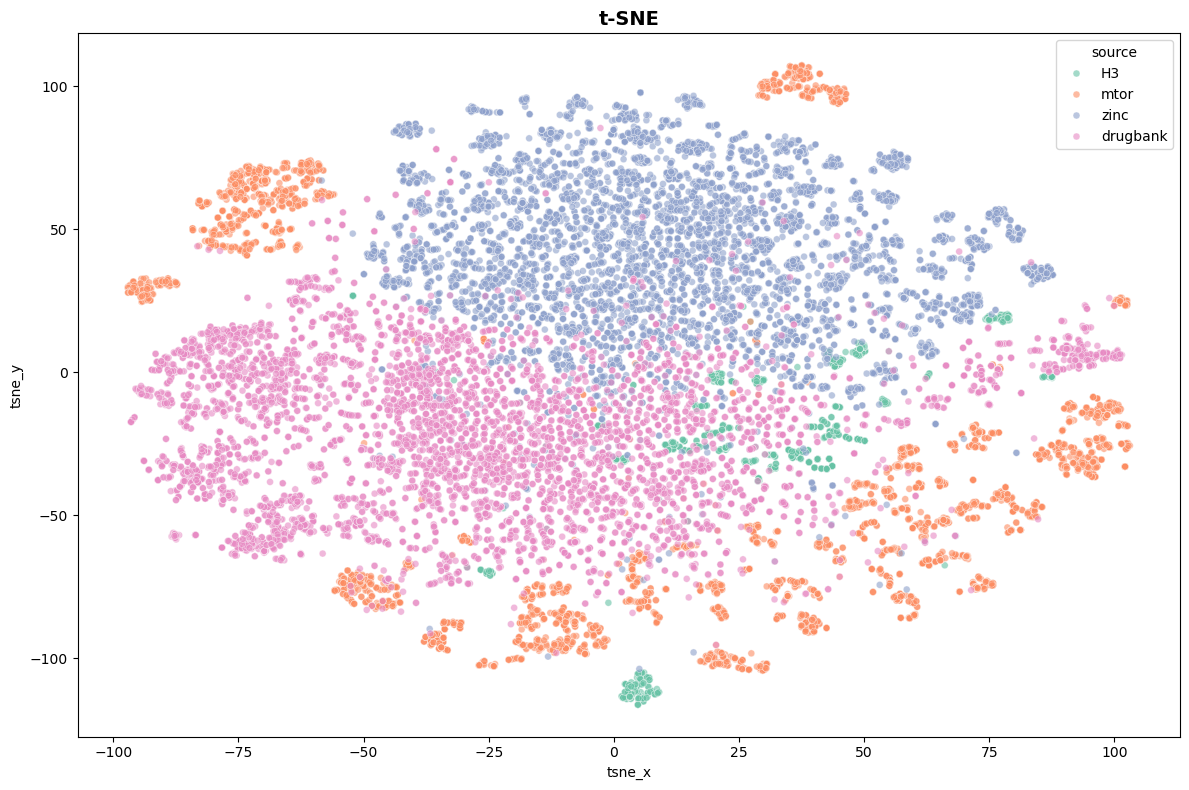

In [158]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=all_structures, x="tsne_x", y="tsne_y",
    hue="source", palette="Set2", alpha=0.6, s=25, ax=ax
)
ax.set_title("t-SNE",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

t-SNE ukazuje výrazně jasnější separaci datasetů než PCA. H3 ligandy tvoří 
oddělené shluky, ZINC je rovnoměrně rozptýlen po celém prostoru, DrugBank a mTOR se překrývají v určitých 
oblastech s H3.

### Strojové učení: Random Forest a XGBoost
Cílem této části je sestavit model, který dokáže na základě struktury 
molekuly předpovědět její biologickou aktivitu vůči H3 receptoru, 
vyjádřenou hodnotou **pChEMBL** ($-\log_{10}$ IC50 v M).


Jako vstupní reprezentaci molekul použijeme **MQN deskriptory**. Srovnáme dva různé algoritmy:

- **Random Forest** — ensemble 200 nezávislých rozhodovacích stromů, 
  výsledek je průměr jejich predikcí
- **XGBoost** — gradient boosting, stromy se přidávají postupně, každý 
  opravuje chyby předchozích

Dataset rozdělíme v poměru **75:25** na trénovací a testovací sadu. 
Trénovací sada slouží k učení modelu, testovací sada k hodnocení reálného výkonu.

In [159]:
df_h3

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL1222870,NaN,NaN,434.56,0.0,3.90,2f,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2CCN(C3CCCCC3)CC2)cc1,IC50,'=',...,CHEMBL1221264,1,Scientific Literature,Bioorg Med Chem Lett,2010,NaN,NaN,NaN,NaN,285.00
1,CHEMBL1223009,NaN,NaN,432.55,0.0,3.65,3e,Fc1ccc(C(c2nnnn2Cc2ccccc2)N2C[C@H]3CC[C@@H](C2...,IC50,'=',...,CHEMBL1221264,1,Scientific Literature,Bioorg Med Chem Lett,2010,NaN,NaN,NaN,NaN,516.00
2,CHEMBL1270059,NaN,NaN,297.44,0.0,3.86,"8, enantiomer",C[C@@H]1C[C@@](O)(CCc2cccc3ccccc23)[C@@H](C)CN1C,IC50,'=',...,CHEMBL1268880,1,Scientific Literature,Bioorg Med Chem Lett,2010,CHEMBL3308396,NaN,NaN,NaN,2.00
3,CHEMBL2403548,NaN,NaN,395.52,0.0,4.76,8a,Cc1cc(N2CC[C@H](N3CCC[C@H]3C)C2)ccc1NC(=O)c1cc...,IC50,'=',...,CHEMBL2401654,1,Scientific Literature,Bioorg Med Chem Lett,2013,NaN,NaN,NaN,NaN,0.66
4,CHEMBL6005581,NaN,NaN,586.63,2.0,6.06,BDBM438125,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OC2C...,IC50,'=',...,CHEMBL5729267,37,BindingDB Patent Bioactivity Data,NaN,2022,NaN,NaN,NaN,NaN,50.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,CHEMBL5570657,NaN,NaN,408.59,0.0,4.58,XX,C[C@@H]1CCCN1CCCOc1ccc2c(c1)CC[C@H]1C3=CCC(=O)...,IC50,'=',...,CHEMBL5528071,1,Scientific Literature,J Med Chem,2024,NaN,TIME = 0.1667 hr,ANTAGONIST,NaN,9.20
1018,CHEMBL5568763,NaN,NaN,410.60,0.0,4.66,XXI,C[C@@H]1CCCN1CCCOc1ccc2c(c1)CC[C@@H]1[C@@H]2CC...,IC50,'=',...,CHEMBL5528071,1,Scientific Literature,J Med Chem,2024,NaN,TIME = 0.1667 hr,ANTAGONIST,NaN,2.60
1019,CHEMBL260374,THIOPERAMIDE,NaN,292.45,0.0,2.80,BDBM22914,S=C(NC1CCCCC1)N1CCC(c2cnc[nH]2)CC1,IC50,'=',...,CHEMBL5729658,37,BindingDB Patent Bioactivity Data,NaN,2023,NaN,NaN,NaN,NaN,140.00
1020,CHEMBL5915995,NaN,NaN,503.54,2.0,6.46,BDBM438114,Cc1nc2ccc(S(F)(F)(F)(F)F)cc2c(=O)n1-c1ccc(OCCC...,IC50,'=',...,CHEMBL5729267,37,BindingDB Patent Bioactivity Data,NaN,2022,NaN,NaN,NaN,NaN,10.50


In [160]:
pchembl = (df_h3[["Molecule ChEMBL ID", "pChEMBL Value"]]
           .dropna(subset=["pChEMBL Value"])
           .drop_duplicates(subset=["Molecule ChEMBL ID"])
           .set_index("Molecule ChEMBL ID"))
pchembl.columns = ["pChEMBL_value"]
pchembl["pChEMBL_value"] = pd.to_numeric(pchembl["pChEMBL_value"], errors="coerce")
pchembl = pchembl.dropna()
print(f"Počet H3 molekul s platnou pChEMBL hodnotou: {len(pchembl)}")
pchembl.head()

Počet H3 molekul s platnou pChEMBL hodnotou: 652


,pChEMBL_value
Molecule ChEMBL ID,
CHEMBL1222870,6.54
CHEMBL1223009,6.29
CHEMBL1270059,8.70
CHEMBL2403548,9.18
CHEMBL6005581,7.30


In [161]:
h3_data = all_structures[all_structures["source"] == "H3"].copy()
h3_data = h3_data.join(pchembl, how="inner")
h3_data = h3_data.groupby(h3_data.index).agg({
    **{c: "first" for c in mqn_cols},
    "pChEMBL_value": "mean",
})
print(f"Velikost finálního datasetu: {len(h3_data)}")
h3_data.head(10)

Velikost finálního datasetu: 652


,MQN_1,MQN_2,MQN_3,MQN_4,MQN_5,MQN_6,MQN_7,MQN_8,MQN_9,MQN_10,...,MQN_34,MQN_35,MQN_36,MQN_37,MQN_38,MQN_39,MQN_40,MQN_41,MQN_42,pChEMBL_value
CHEMBL1091874,15,0,1,0,0,0,0,2,3,0,...,0,2,2,0,0,0,0,4,2,5.24
CHEMBL1172774,18,0,0,0,0,0,0,0,3,0,...,0,1,2,0,0,0,0,0,0,8.18
CHEMBL1173391,21,0,0,0,0,0,0,0,3,0,...,0,1,3,0,0,0,0,0,0,6.46
CHEMBL1190,16,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,6.09
CHEMBL1221424,26,0,0,0,0,0,0,0,6,0,...,1,2,2,1,0,0,0,2,1,7.23
CHEMBL1221429,26,0,0,0,0,0,0,1,6,1,...,1,1,2,1,0,0,0,0,0,8.52
CHEMBL1222433,29,0,0,0,0,0,0,0,7,0,...,1,1,3,1,0,0,0,0,0,9.22
CHEMBL1222434,29,0,0,0,0,0,0,0,8,0,...,1,1,3,1,0,0,0,0,0,9.30
CHEMBL1222435,28,0,0,0,0,0,0,0,7,0,...,1,2,2,1,0,0,0,0,0,8.19
CHEMBL1222436,27,0,0,0,0,0,0,0,8,0,...,1,2,2,1,0,0,0,0,0,8.92


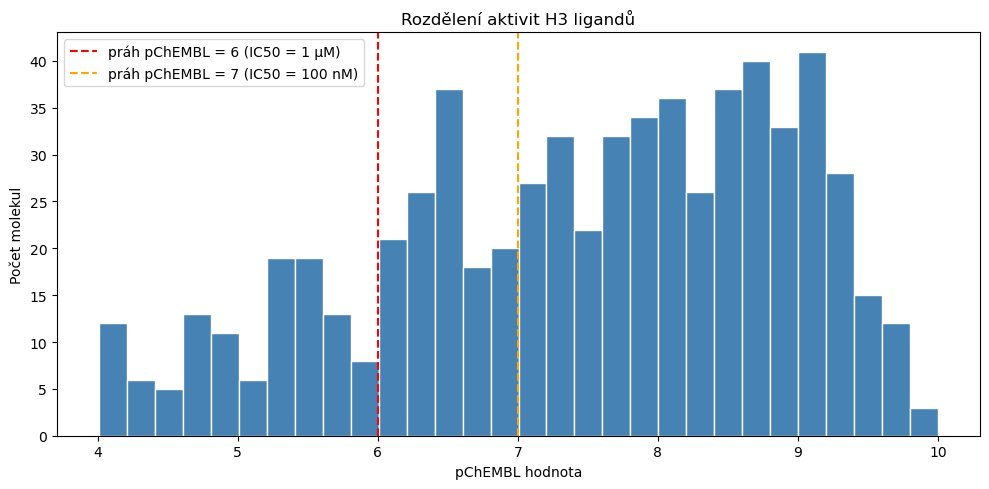

Celkem molekul: 652
pChEMBL >= 5: 608
pChEMBL >= 6: 540
pChEMBL >= 7: 418


In [162]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(h3_data["pChEMBL_value"], bins=30, edgecolor="white", color="steelblue")
ax.axvline(x=6, color="red", linestyle="--", label="práh pChEMBL = 6 (IC50 = 1 μM)")
ax.axvline(x=7, color="orange", linestyle="--", label="práh pChEMBL = 7 (IC50 = 100 nM)")
ax.set_xlabel("pChEMBL hodnota")
ax.set_ylabel("Počet molekul")
ax.set_title("Rozdělení aktivit H3 ligandů")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Celkem molekul: {len(h3_data)}")
print(f"pChEMBL >= 5: {(h3_data['pChEMBL_value'] >= 5).sum()}")
print(f"pChEMBL >= 6: {(h3_data['pChEMBL_value'] >= 6).sum()}")
print(f"pChEMBL >= 7: {(h3_data['pChEMBL_value'] >= 7).sum()}")

In [163]:
def get_results(model, data, descriptors, predicted_value):
    """Výpočet predikce, průměrné absolutní chyby"""
    res = pd.DataFrame(model.predict(data[descriptors])).join(
        data[[predicted_value]].reset_index(drop=True)
    )
    res.columns = ["Prediction", predicted_value]
    avg_error = (res["Prediction"] - res[predicted_value]).abs().mean()
    print(f"Průměrná chyba: {avg_error:.3f}")
    return res

In [164]:
trainset, testset = ms.train_test_split(h3_data, test_size=0.25, random_state=42)
trainset = trainset.reset_index(drop=True)
testset = testset.reset_index(drop=True)

print(f"Trénovací set: {len(trainset)} molekul")
print(f"Testovací set: {len(testset)} molekul")

Trénovací set: 489 molekul
Testovací set: 163 molekul


In [165]:
model_rf = ensemble.RandomForestRegressor(random_state=42)
model_rf.fit(trainset[mqn_cols], trainset["pChEMBL_value"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

R² - jak dobře model vysvětluje rozptyl
MSE - střední kvadratická chyba
MAE - průměrná absolutní chyba v pChEMBL jednotkách

In [166]:
print("--- Train ---")
train_results = get_results(model_rf, trainset, mqn_cols, "pChEMBL_value")
print("--- Test ---")
test_results = get_results(model_rf, testset, mqn_cols, "pChEMBL_value")

--- Train ---
Průměrná chyba: 0.281
--- Test ---
Průměrná chyba: 0.631


In [167]:
print("R²:  %.2f" % model_rf.score(testset[mqn_cols], testset["pChEMBL_value"]))
print("MSE: %.2f" % mean_squared_error(test_results["Prediction"],
                                       test_results["pChEMBL_value"]))

R²:  0.58
MSE: 0.73


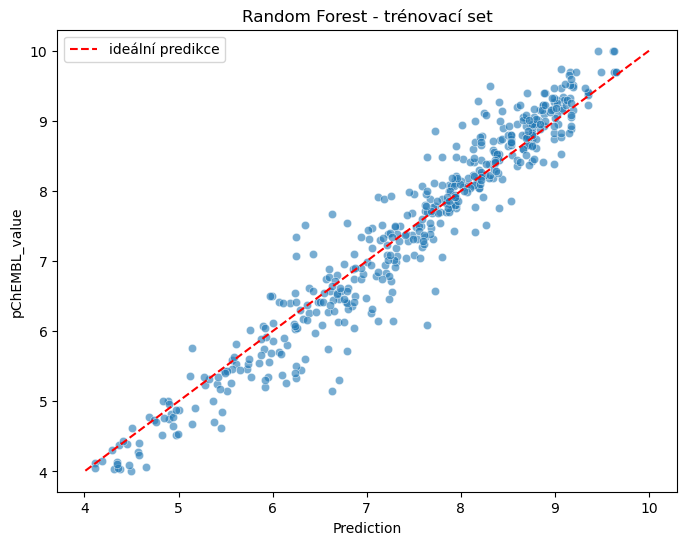

In [168]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x="Prediction", y="pChEMBL_value", data=train_results,
                ax=ax, alpha=0.6)
lims = [train_results.min().min(), train_results.max().max()]
ax.plot(lims, lims, 'r--', label='ideální predikce')
ax.set_title('Random Forest - trénovací set')
ax.legend()
plt.show()

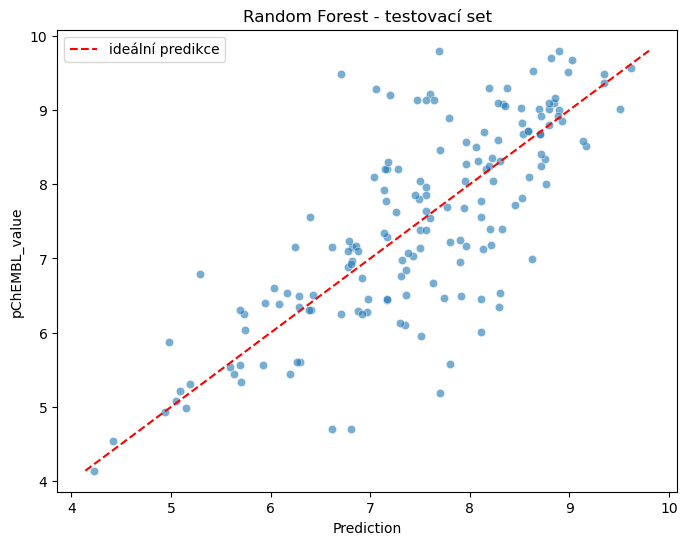

In [169]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x="Prediction", y="pChEMBL_value", data=test_results,
                ax=ax, alpha=0.6)
lims = [test_results.min().min(), test_results.max().max()]
ax.plot(lims, lims, 'r--', label='ideální predikce')
ax.set_title('Random Forest - testovací set')
ax.legend()
plt.show()

In [170]:
X_train = trainset[mqn_cols]
y_train = trainset["pChEMBL_value"]
X_test  = testset[mqn_cols]
y_test  = testset["pChEMBL_value"]

model_xgb = xg.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
model_xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [171]:
print("--- Train ---")
train_results_xgb = get_results(model_xgb, trainset, mqn_cols, "pChEMBL_value")
print("--- Test ---")
test_results_xgb = get_results(model_xgb, testset, mqn_cols, "pChEMBL_value")

--- Train ---
Průměrná chyba: 0.198
--- Test ---
Průměrná chyba: 0.612


In [172]:
print("R²:  %.2f" % model_xgb.score(X_test, y_test))
print("MSE: %.2f" % mean_squared_error(test_results_xgb["Prediction"],
                                       test_results_xgb["pChEMBL_value"]))

R²:  0.61
MSE: 0.69


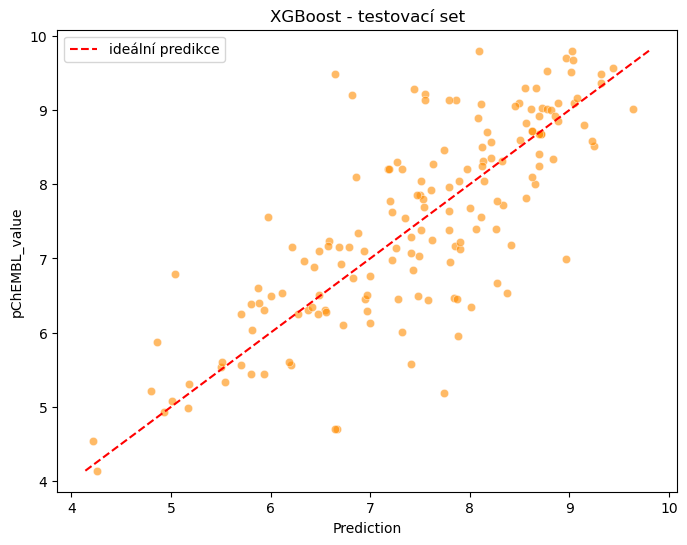

In [173]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x="Prediction", y="pChEMBL_value", data=test_results_xgb,
                ax=ax, alpha=0.6, color='darkorange')
lims = [test_results_xgb.min().min(), test_results_xgb.max().max()]
ax.plot(lims, lims, 'r--', label='ideální predikce')
ax.set_title('XGBoost - testovací set')
ax.legend()
plt.show()